# Implementacion de Modelos de Machine Learning
A partir de los datos limpios realizados en la fase de limpieza de datos valga la redundancia, es posible comenzar a plantear la implementacion de modelos de machine learning de distintos tipos como regresiones, arboles o SVMs, sin embargo antes de ello es necesario realizar algunos ajustes a los datos limpios que se adecuen al proposito, problema o tarea a resolver que vayan a tener.

En este caso, se opto por que los modelos puedan predecir datos de casos de COVID-19 nuevos en una fecha determinada en China.

A lo largo de este documento se mostrara el proceso de adecuacion de los datos limpios para determinar la segregacion de los mismos en datos de entrenamiento y datos de prueba y eventualmente el aprendizaje de los modelos como tal.

# 1. Preparacion del Dataset Limpio

## 1.1. Inicializacion de Librerias y Datos
Se importan las siguientes librerias para lograr la implementacion de los modelos de regresion, arboles y SVMs:
- **os:** libreria del sistema operativo para el manejo de importacion de los archicos csv.
- **pandas:** libreria principal para el analisis de datos y consultas rapidas de las tablas importadas
- **numpy:** libreria para facilitar y optimizar operaciones matematicas y operaciones con listas con cantidades gigantes de valores.
- **scikit learn:** libreria para la importacion de modelos preimplementados de diferentes tipos y pipelines para unificar diferentes modelos y modificar sus caracteristicas.
- **Seaborn y MatPlotLib:** libreria para la creacion de graficos estadisticos.

In [2]:
import os
import sys
from pathlib import Path
import gdown
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (mean_absolute_error,
  mean_squared_error, mean_absolute_percentage_error, r2_score, max_error)
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

Se inicializa las variables necesarias para reconocer las rutas y el entorno en donde se descargaran los datasets.

In [3]:
EN_COLAB = "google.colab" in sys.modules
BASE_DIR = Path("/content") if EN_COLAB else Path.cwd().parent.parent
DATA_DIR = BASE_DIR / "dataset_limpio"
DATA_DIR.mkdir(parents=True, exist_ok=True)

DRIVE_URL = "https://drive.google.com/drive/folders/1I5_LlASamoO8H5WHDn1yjBZTTisT7wBg?usp=sharing"

USAR_SHEETS = True

print("Entorno:", "Google Colab" if EN_COLAB else "Local")
print("Datos limpios en:", DATA_DIR)

Entorno: Local
Datos limpios en: /home/azurduy/Universidad/machine-learning-primer-parcial/dataset_limpio


## 1.2. Extraccion de Datos
Por medio de la libreria gdown se accede al directorio donde se ubica la carpeta "dataset_limpio" que contiene los archivos .csv limpiados con anterioridad.

De todos los archivos .csv limpios, se escoge exclusivamente los siguientes:
- **confirmed_cleaned.csv** almacenado en la variabla *confirmed*
- **deaths_cleaned.csv** almacenado en la variabla *deaths*
- **recovered_cleaned.csv** almacenado en la variabla *recovered*

Se descartan los archivos de **deaths_US_cleaned.csv** y **confirmed_US_cleaned** puesto que como grupo se definio que el alcance del modelo se centrara en la prediccion de casos nuevos confirmados de COVID-19 en un determinado dia en cualquier otro pais distinto a USA, ademas tambien se descarta el archivo **global_data_cleaned.csv**, ya que contiene informacion muy general que no se considero lo suficientemente util para el proposito mencionado.



In [4]:
ARCHIVOS = {
    "confirmed": "confirmed_cleaned.csv",
    "deaths":    "deaths_cleaned.csv",
    "recovered": "recovered_cleaned.csv",
}

def buscar(nombre):
    """Busca el archivo dentro de DATA_DIR (incluso en subcarpetas)."""
    return next(DATA_DIR.rglob(nombre), None)

if any(buscar(n) is None for n in ARCHIVOS.values()):
    print("Descargando datasets limpios desde Google Drive...")
    gdown.download_folder(DRIVE_URL, output=str(DATA_DIR), quiet=False)

faltantes = [n for n in ARCHIVOS.values() if buscar(n) is None]
if faltantes:
    raise FileNotFoundError(
        f"No se encontraron: {faltantes}. Coloca los CSV en '{DATA_DIR}' y vuelve a ejecutar."
    )

confirmed = pd.read_csv(buscar(ARCHIVOS["confirmed"]))
deaths    = pd.read_csv(buscar(ARCHIVOS["deaths"]))
recovered = pd.read_csv(buscar(ARCHIVOS["recovered"]))

Es necesario dar forma a los contenidos extraidos anteriormente y almacenados en las variables de *confirmed, deaths* y *recovered*, para ello se transforman en la estructura de datos: Data Frame propia de la libreria de pandas para una mejor visualizacion, manipulacion y tratamiento de los datos.

In [5]:
#Data Frames iniciales para casos confirmados nuevos, decesos y recuperaciones
df_c = pd.DataFrame(confirmed)
df_d = pd.DataFrame(deaths)
df_r = pd.DataFrame(recovered)

# 2. Estandarizacion y Adaptacion de los Datos para los Modelos


## 2.1. Pivotado Aplicado para cada Tabla
Inicialmente es necesario conocer como estan originalmente los datos en las tablas extraidas, para el caso de las tablas que reflejan tanto los datos de casos confirmados, decesos y recuperaciones es posible notar que existe una anomalia particular en las tablas, y es que se tienen multiples columnas dedicadas exclusivamente a mostrar la cantidad de casos confirmados, muertes o recuperaciones hasta hasta una fecha especifica.

Desde un punto de vista humano es una forma de notacion sencilla para visualizar e insertar datos acumulativos, pero, en la practica, para el analisis de los datos y la adaptacion de los mismos al modelo suele ser bastante incomodo.

In [6]:
print("Tabla de casos confirmados antes de aplicar el pivoteo:", "\n")
df_c.head()

Tabla de casos confirmados antes de aplicar el pivoteo: 



,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,unknown,afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,64575,65080,65486,65728,66275,66903,67743,68366,69130,70111
1,unknown,albania,41.15330,20.168300,0,0,0,0,0,0,...,132118,132153,132176,132209,132215,132229,132244,132264,132285,132297
2,unknown,algeria,28.03390,1.659600,0,0,0,0,0,0,...,126156,126434,126651,126860,127107,127361,127646,127926,128198,128456
3,unknown,andorra,42.50630,1.521800,0,0,0,0,0,0,...,13569,13569,13569,13569,13569,13664,13671,13682,13693,13693
4,unknown,angola,-11.20270,17.873900,0,0,0,0,0,0,...,31661,31909,32149,32441,32623,32933,33338,33607,33944,34180


Por ello se aplica una tecnica de adaptacion de los datos llamada *melt* o *pivotado*, la cual permite unificar las multiples columnas con fechas especificas en una sola columna que se denominara *Date* para este caso, ademas, esta funcion permite que se generen nuevas filas por todos y cada uno de los valores que se reflejaban en las columnas eliminadas, pasando de una notacion vertical a una horizontal.

Ademas de ello, la funcion *melt* permite especificar que columnas deberan de mantenerse sin modificacion, que en este caso son las columnas comunes en todas las tablas de: **Province/State, Country/Region, Lat** y **Long**. Este proceso se aplicara para las 3 tablas establecidas como se observa a continuacion:

In [7]:
#Pivotado aplicado a la tabla de casos confirmados:
df_c_formated = df_c.melt(
    id_vars = ["Province/State", "Country/Region", "Lat", "Long"],
    var_name = "Date",
    value_name = "Confirmed"
)

In [8]:
print("Tabla de casos confirmados despues de aplicar el pivoteo:", "\n")
df_c_formated.head()

Tabla de casos confirmados despues de aplicar el pivoteo: 



,Province/State,Country/Region,Lat,Long,Date,Confirmed
0,unknown,afghanistan,33.93911,67.709953,1/22/20,0
1,unknown,albania,41.15330,20.168300,1/22/20,0
2,unknown,algeria,28.03390,1.659600,1/22/20,0
3,unknown,andorra,42.50630,1.521800,1/22/20,0
4,unknown,angola,-11.20270,17.873900,1/22/20,0


In [9]:
print("Tabla de decesos registrados antes de aplicar el pivoteo:", "\n")
df_d.head()

Tabla de decesos registrados antes de aplicar el pivoteo: 



,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,unknown,afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,2772,2782,2792,2802,2812,2836,2855,2869,2881,2899
1,unknown,albania,41.15330,20.168300,0,0,0,0,0,0,...,2440,2441,2442,2444,2445,2447,2447,2447,2448,2449
2,unknown,algeria,28.03390,1.659600,0,0,0,0,0,0,...,3401,3405,3411,3418,3426,3433,3440,3448,3455,3460
3,unknown,andorra,42.50630,1.521800,0,0,0,0,0,0,...,127,127,127,127,127,127,127,127,127,127
4,unknown,angola,-11.20270,17.873900,0,0,0,0,0,0,...,704,709,715,725,731,735,742,745,749,757


In [10]:
#Pivotado aplicado a la tabla de decesos registrados:
df_d_formated = df_d.melt(
    id_vars = ["Province/State", "Country/Region", "Lat", "Long"],
    var_name = "Date",
    value_name = "Deaths"
)

In [11]:
print("Tabla de decesos registrados despues de aplicar el pivoteo:", "\n")
df_d_formated.head()

Tabla de decesos registrados despues de aplicar el pivoteo: 



,Province/State,Country/Region,Lat,Long,Date,Deaths
0,unknown,afghanistan,33.93911,67.709953,1/22/20,0
1,unknown,albania,41.15330,20.168300,1/22/20,0
2,unknown,algeria,28.03390,1.659600,1/22/20,0
3,unknown,andorra,42.50630,1.521800,1/22/20,0
4,unknown,angola,-11.20270,17.873900,1/22/20,0


In [12]:
print("Tabla de recuperaciones registradas antes de aplicar el pivoteo:", "\n")
df_r.head()

Tabla de recuperaciones registradas antes de aplicar el pivoteo: 



,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,unknown,afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,55687,55790,55889,56035,56295,56518,56711,56962,57119,57281
1,unknown,albania,41.15330,20.168300,0,0,0,0,0,0,...,127869,128425,128601,128732,128826,128907,128978,129042,129097,129215
2,unknown,algeria,28.03390,1.659600,0,0,0,0,0,0,...,87902,88066,88208,88346,88497,88672,88861,89040,89232,89419
3,unknown,andorra,42.50630,1.521800,0,0,0,0,0,0,...,13234,13234,13234,13234,13234,13263,13381,13405,13416,13416
4,unknown,angola,-11.20270,17.873900,0,0,0,0,0,0,...,26483,26513,26775,26778,27087,27204,27467,27529,27577,27646


In [13]:
#Pivotado aplicado a la tabla de decesos registrados:
df_r_formated = df_r.melt(
    id_vars = ["Province/State", "Country/Region", "Lat", "Long"],
    var_name = "Date",
    value_name = "Recoveries"
)

In [14]:
print("Tabla de recuperaciones registradas despues de aplicar el pivoteo:", "\n")
df_r_formated.head()

Tabla de recuperaciones registradas despues de aplicar el pivoteo: 



,Province/State,Country/Region,Lat,Long,Date,Recoveries
0,unknown,afghanistan,33.93911,67.709953,1/22/20,0
1,unknown,albania,41.15330,20.168300,1/22/20,0
2,unknown,algeria,28.03390,1.659600,1/22/20,0
3,unknown,andorra,42.50630,1.521800,1/22/20,0
4,unknown,angola,-11.20270,17.873900,1/22/20,0


## 2.2. Ajuste de Tipos de Dato para Fechas
Tras realizar el pivotado en cada tabla, es posible apreciar que la columna generada *Date* es de tipo object sumado a que visiblemente no presenta el formato estandar que deberian de presentar sus valores al ser fechas. Con motivos de facilitar calculos posteriores como la identificacion del dia de la semana correspondiente es necesario transformar ese tipo de dato a el tipo de dato de fechas estandar que ofrece la libreria de pandas.

In [15]:
df_c_formated.info()

<class 'pandas.DataFrame'>
RangeIndex: 135356 entries, 0 to 135355
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Province/State  135356 non-null  str    
 1   Country/Region  135356 non-null  str    
 2   Lat             135356 non-null  float64
 3   Long            135356 non-null  float64
 4   Date            135356 non-null  str    
 5   Confirmed       135356 non-null  int64  
dtypes: float64(2), int64(1), str(3)
memory usage: 6.2 MB


Para aplicar la conversion de tipo de dato object a tipo fecha se emplea el uso de la funcion *to_datetime* propia de pandas que recibe como parametros la coluumna de la tabla que se desea convertir y el formato especifico especificado con expresiones regulares o regex.

In [16]:
df_c_formated["Date"] = pd.to_datetime(df_c_formated["Date"], format = "%m/%d/%y")

Tras aplicar la transformacion, se puede notar que la columna *Date* ahora presenta el tipo de dato estandar para fechas que es *datetime64[ms]*, ademas de que visiblemente el formato correspondiente especificado en la expresion regular denota la forma anio-mes-dia.

In [17]:
df_c_formated.info()

<class 'pandas.DataFrame'>
RangeIndex: 135356 entries, 0 to 135355
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Province/State  135356 non-null  str           
 1   Country/Region  135356 non-null  str           
 2   Lat             135356 non-null  float64       
 3   Long            135356 non-null  float64       
 4   Date            135356 non-null  datetime64[us]
 5   Confirmed       135356 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 6.2 MB


In [18]:
print("Valores de la columna Date despues de la conversion de tipos:", "\n")
df_c_formated.head()

Valores de la columna Date despues de la conversion de tipos: 



,Province/State,Country/Region,Lat,Long,Date,Confirmed
0,unknown,afghanistan,33.93911,67.709953,2020-01-22,0
1,unknown,albania,41.15330,20.168300,2020-01-22,0
2,unknown,algeria,28.03390,1.659600,2020-01-22,0
3,unknown,andorra,42.50630,1.521800,2020-01-22,0
4,unknown,angola,-11.20270,17.873900,2020-01-22,0


El proceso de conversion de tipos de dato de fecha a la columna *Date* se acaba de aplicar solamente a la tabla de casos confirmados, sin embargo tambien es aplicable a las tablas de decesos y recuperaciones registradas, ya que tambien por resultado del pivoteo tambien cuentan con dicha columna.

In [19]:
#Transformacion de tipo de dato object a fecha en la tabla de decesos registrados:
df_d_formated["Date"] = pd.to_datetime(df_d_formated["Date"], format = "%m/%d/%y")
#Transformacion de tipo de dato object a fecha en la tabla de recuperaciones registradas:
df_r_formated["Date"] = pd.to_datetime(df_r_formated["Date"], format = "%m/%d/%y")

In [20]:
print("Informacion de columnas de la tabla de decesos registrados despues de la conversion de tipos:", "\n")
df_d_formated.info()

Informacion de columnas de la tabla de decesos registrados despues de la conversion de tipos: 

<class 'pandas.DataFrame'>
RangeIndex: 135356 entries, 0 to 135355
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Province/State  135356 non-null  str           
 1   Country/Region  135356 non-null  str           
 2   Lat             135356 non-null  float64       
 3   Long            135356 non-null  float64       
 4   Date            135356 non-null  datetime64[us]
 5   Deaths          135356 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 6.2 MB


In [21]:
print("Informacion de columnas de la tabla de recuperaciones registrados despues de la conversion de tipos:", "\n")
df_r_formated.info()

Informacion de columnas de la tabla de recuperaciones registrados despues de la conversion de tipos: 

<class 'pandas.DataFrame'>
RangeIndex: 128440 entries, 0 to 128439
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Province/State  128440 non-null  str           
 1   Country/Region  128440 non-null  str           
 2   Lat             128440 non-null  float64       
 3   Long            128440 non-null  float64       
 4   Date            128440 non-null  datetime64[us]
 5   Recoveries      128440 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 5.9 MB


## 2.3. Confirmacion de Valores Negativos
Antes de continuar con la adecuacion de los datos, se hace una pequenia verificacion para ver si es que no existe ningun valor registrado negativo en las columnas de *Confirmed, Deaths* y *Recoveries* para las tablas de casos confirmados, decesos y recuperaciones registradas respectivamente.

Como se observa en el codigo, el conteo de esta clase de valores en casa una de las columnas mencionadas es 0, por lo que no es necesario efectuar una limpieza instantanea para tratarlos.

In [22]:
print("Cantidad de filas con casos confirmados acumulados negativos:", df_c_formated[df_c_formated["Confirmed"] < 0].shape[0])
print("Cantidad de filas con cantidad de muertes acumuladas negativos:", df_d_formated[df_d_formated["Deaths"] < 0].shape[0])
print("Cantidad de filas con cantidad de recuperados acumulados negativos:", df_r_formated[df_r_formated["Recoveries"] < 0].shape[0])

Cantidad de filas con casos confirmados acumulados negativos: 0
Cantidad de filas con cantidad de muertes acumuladas negativos: 0
Cantidad de filas con cantidad de recuperados acumulados negativos: 0


## 2.4. Serializacion de Frecuencias para cada Tabla
Este procedimiento surge a base de que se considera que toda los valores numericos registrados son de caracter acumulado con el paso de las fechas, respondiendo a lo que serian "frecuencias acumuladas."

Esta manera de representar la aparicion de nuevos casos confirmados, decesos y recuperaciones no es de utilidad para el proceso de aprendizaje aplicando los modelos, ya que no es informacion suficiente, sobre todo porque no refleja el factor cronologico que es vital en este dataset y que le da sentido a las acumulaciones.

A continuacion se hara la explicacion detallada en base a la tabla de casos confirmados.

### 2.4.1. Analisis Detallado del Procedimiento con la Tabla de Casos Confirmados

Por ello lo mejor es simplemente indicar cuantos nuevos casos, decesos o recuperaciones respectivamente para cada tabla se dieron en una fecha (fila) especifica, para ello se agrupan las tablas por las caracteristicas comunes de **Country/Region** y **Province/State**.

Luego se crea una nueva columna, para el caso de la tabla de casos confirmados la columna *New Cases*, que contendra la diferencia de los valores de la columna de casos confirmados acumulados desde el inicio (**Confirmed**) y la misma columna desfasada una fecha o dia atras (funcion *diff*) dando como resultado valores no acumulados, variados y serializados.

In [23]:
df_c_formated = df_c_formated.sort_values(["Country/Region", "Province/State"])
df_c_formated["New Cases"] = df_c_formated.groupby(["Country/Region", "Province/State"])["Confirmed"].diff()

In [24]:
print("Tabla de casos confirmados con la columna serializada agregada:", "\n")
df_c_formated.head()

Tabla de casos confirmados con la columna serializada agregada: 



,Province/State,Country/Region,Lat,Long,Date,Confirmed,New Cases
0,unknown,afghanistan,33.93911,67.709953,2020-01-22,0,NaN
274,unknown,afghanistan,33.93911,67.709953,2020-01-23,0,0.0
548,unknown,afghanistan,33.93911,67.709953,2020-01-24,0,0.0
822,unknown,afghanistan,33.93911,67.709953,2020-01-25,0,0.0
1096,unknown,afghanistan,33.93911,67.709953,2020-01-26,0,0.0


Pese a haber obtenido valores no acumulados, la serializacion presenta un problema, y es que algunos de los valores no acumulados terminan siendo negativos, que para este caso en concreto, representan que de una fecha a otra los valores de la columna **Confirmed** en lugar de haber un sufrido aumento acumulativo coherente de casos confirmados hubo decremento, cosa que es inconsistente al ser un valor que solo acumula e inevitablemente por registrar casos nuevos desde el primer dia como se observa:

In [25]:
negative_rows = sum(map(lambda val: 1 if (val < 0) else 0, df_c_formated["New Cases"]))
print("Cantidad de filas con casos nuevos negativos:", negative_rows, "\n")
df_c_formated[df_c_formated["New Cases"] < 0]

Cantidad de filas con casos nuevos negativos: 138 



,Province/State,Country/Region,Lat,Long,Date,Confirmed,New Cases
44667,unknown,antigua and barbuda,17.060800,-61.796400,2020-07-03,68,-1.0
129607,unknown,antigua and barbuda,17.060800,-61.796400,2021-05-09,1231,-1.0
22476,australian capital territory,australia,-35.473500,149.012400,2020-04-13,102,-1.0
27957,new south wales,australia,-33.868800,151.209300,2020-05-03,3033,-2.0
34259,new south wales,australia,-33.868800,151.209300,2020-05-26,3089,-3.0
...,...,...,...,...,...,...,...
121646,unknown,united kingdom,55.378100,-3.436000,2021-04-09,4365461,-4860.0
132332,unknown,united kingdom,55.378100,-3.436000,2021-05-18,4450392,-2364.0
22459,unknown,uruguay,-32.522800,-55.765800,2020-04-12,480,-21.0
55619,unknown,yemen,15.552727,48.516388,2020-08-11,1831,-1.0


Las filas con valores no acumulados negativos simplemente no pueden ser eliminados, ya que de hacerlo se puede romper la continuidad cronologica de los registros de la tabla.

La estrategia por tanto, sera sustituir aquellos valores acumulados de la columna **Confirmed** que tras aplicar la funcion *diff* generan valores negativos por otros valores positivos, los cuales no son nada mas que la ultima ocurrencia positiva de mayor valor anterior, empleando la funcion *cummax*.

Como observacion importante a considerar tambien, es que es necesario el agrupar por **Probince/State** y **Country/Region**, ya que existen casos bordes en el reemplazo de los valores acumulados provocadores de valores negativos no acumulados en los que puede que exista una ocurrencia positiva anterior no correspondiente ni al pais ni al estado al que pertenece originalmente el valor problematico, el remplazar dicho valor con un valor no correspondiente a su grupo puede generar ruido y cesgo al momento de usar los datos en el entrenamiento del modelo.

In [26]:
df_c_formated["Confirmed"] = df_c_formated.groupby(["Country/Region", "Province/State"])["Confirmed"].cummax()

Finalmente tras haber limpiado los valores acumulados de la columna **Confirmed** que generan valores negativos no acumulados de la serializacion, lo ultimo por hacer es recalcular los valores no acumulados nuevamente aplicando la serializacion con la funcion *diff*, en teoria ya no deberia existir la posibilidad de aparicion de filas con valores no acumulados negativos.

In [27]:
df_c_formated = df_c_formated.sort_values(["Country/Region", "Province/State"])
df_c_formated["New Cases"] = df_c_formated.groupby(["Country/Region", "Province/State"])["Confirmed"].diff()

Efectivamente, como se puede apreciar en el codigo, el ajuste de valor maximo anterior en valores acumulados problematicos de la columna **Confirmed** aplicando la funcion *cummax* garantizo la depuracion de valores negativos no acumulados de forma controlada por grupos por pais y estado.

In [28]:
negative_rows = sum(map(lambda val: 1 if (val < 0) else 0, df_c_formated["New Cases"]))
print("Cantidad de filas con casos nuevos negativos:", negative_rows, "\n")
df_c_formated[df_c_formated["New Cases"] < 0]

Cantidad de filas con casos nuevos negativos: 0 



,Province/State,Country/Region,Lat,Long,Date,Confirmed,New Cases


### 2.4.2. Serializacion y Control de Valores Negativos en Tablas de Decesos y Recuperaciones Registradas
El proceso de serializacion explicado tambien es aplicable a las tablas de decesos y recuperaciones registradas, al ser tablas con columnas parecidas, con la diferencia de que se deben producir los valores no acumulados a partir de las columnas **Deaths** y **Recoveries** respectivamente paea cada tabla.

In [29]:
#Calculo de la columna New Deaths para valores no acumulados de nuevos decesos registrados por fecha:
df_d_formated = df_d_formated.sort_values(["Country/Region", "Province/State"])
df_d_formated["New Deaths"] = df_d_formated.groupby(["Country/Region", "Province/State"])["Deaths"].diff()

In [30]:
print("Tabla de decesos registrados con la columna serializada agregada:", "\n")
df_d_formated.head()

Tabla de decesos registrados con la columna serializada agregada: 



,Province/State,Country/Region,Lat,Long,Date,Deaths,New Deaths
0,unknown,afghanistan,33.93911,67.709953,2020-01-22,0,NaN
274,unknown,afghanistan,33.93911,67.709953,2020-01-23,0,0.0
548,unknown,afghanistan,33.93911,67.709953,2020-01-24,0,0.0
822,unknown,afghanistan,33.93911,67.709953,2020-01-25,0,0.0
1096,unknown,afghanistan,33.93911,67.709953,2020-01-26,0,0.0


In [31]:
negative_rows = sum(map(lambda val: 1 if (val < 0) else 0, df_d_formated["New Deaths"]))
print("Cantidad de filas con valores de nuevas muertes registradas negativos:", negative_rows, "\n")
df_d_formated[df_d_formated["New Deaths"] < 0]

Cantidad de filas con valores de nuevas muertes registradas negativos: 104 



,Province/State,Country/Region,Lat,Long,Date,Deaths,New Deaths
71244,unknown,angola,-11.202700,17.873900,2020-10-08,208,-3.0
35905,queensland,australia,-27.469800,153.025100,2020-06-01,6,-1.0
49610,unknown,austria,47.516200,14.550100,2020-07-21,710,-1.0
72078,unknown,austria,47.516200,14.550100,2020-10-11,851,-1.0
59481,unknown,belgium,50.833300,4.469936,2020-08-26,9879,-117.0
...,...,...,...,...,...,...,...
28753,channel islands,united kingdom,49.372300,-2.364400,2020-05-05,40,-1.0
41905,channel islands,united kingdom,49.372300,-2.364400,2020-06-22,47,-1.0
16702,"saint helena, ascension and tristan da cunha",united kingdom,-7.946700,-14.355900,2020-03-22,0,-1.0
27668,unknown,venezuela,6.423800,-66.589700,2020-05-01,10,-6.0


In [32]:
#Reemplazo de valores acumulados de la columna Deaths que provocan valores negativos no acumulados:
df_d_formated["Deaths"] = df_d_formated.groupby(["Country/Region", "Province/State"])["Deaths"].cummax()

In [33]:
#Recalculo de la columna serializada New Deaths para los valores no acumulados tras el ajuste:
df_d_formated = df_d_formated.sort_values(["Country/Region", "Province/State"])
df_d_formated["New Deaths"] = df_d_formated.groupby(["Country/Region", "Province/State"])["Deaths"].diff()

In [34]:
negative_rows = sum(map(lambda val: 1 if (val < 0) else 0, df_d_formated["New Deaths"]))
print("Cantidad de filas con valores de nuevas muertes registradas negativos:", negative_rows, "\n")
df_d_formated[df_d_formated["New Deaths"] < 0]

Cantidad de filas con valores de nuevas muertes registradas negativos: 0 



,Province/State,Country/Region,Lat,Long,Date,Deaths,New Deaths


In [35]:
#Calculo de la columna New Recoveries para valores no acumulados de nuevas recuperaciones registrados por fecha:
df_r_formated = df_r_formated.sort_values(["Country/Region", "Province/State"])
df_r_formated["New Recoveries"] = df_r_formated.groupby(["Country/Region", "Province/State"])["Recoveries"].diff()

In [36]:
print("Tabla de recuperaciones registrados con la columna serializada agregada:", "\n")
df_r_formated.head()

Tabla de recuperaciones registrados con la columna serializada agregada: 



,Province/State,Country/Region,Lat,Long,Date,Recoveries,New Recoveries
0,unknown,afghanistan,33.93911,67.709953,2020-01-22,0,NaN
260,unknown,afghanistan,33.93911,67.709953,2020-01-23,0,0.0
520,unknown,afghanistan,33.93911,67.709953,2020-01-24,0,0.0
780,unknown,afghanistan,33.93911,67.709953,2020-01-25,0,0.0
1040,unknown,afghanistan,33.93911,67.709953,2020-01-26,0,0.0


In [37]:
negative_rows = sum(map(lambda val: 1 if (val < 0) else 0, df_r_formated["New Recoveries"]))
print("Cantidad de filas con valores de nuevas recuperaciones registradas negativos:", negative_rows, "\n")
df_r_formated[df_r_formated["New Recoveries"] < 0]

Cantidad de filas con valores de nuevas recuperaciones registradas negativos: 226 



,Province/State,Country/Region,Lat,Long,Date,Recoveries,New Recoveries
108160,unknown,afghanistan,33.939110,67.709953,2021-03-13,49471,-28.0
16122,unknown,algeria,28.033900,1.659600,2020-03-24,24,-41.0
16642,unknown,algeria,28.033900,1.659600,2020-03-26,29,-36.0
32242,unknown,algeria,28.033900,1.659600,2020-05-25,4747,-37.0
13263,unknown,andorra,42.506300,1.521800,2020-03-13,0,-1.0
...,...,...,...,...,...,...,...
25475,unknown,vietnam,14.058324,108.277199,2020-04-28,222,-3.0
25995,unknown,vietnam,14.058324,108.277199,2020-04-30,219,-3.0
53035,unknown,vietnam,14.058324,108.277199,2020-08-12,409,-42.0
19756,unknown,west bank and gaza,31.952200,35.233200,2020-04-06,24,-1.0


In [38]:
#Reemplazo de valores acumulados de la columna Recoveries que provocan valores negativos no acumulados:
df_r_formated["Recoveries"] = df_r_formated.groupby(["Country/Region", "Province/State"])["Recoveries"].cummax()

In [39]:
#Recalculo de la columna serializada New Recoveries para los valores no acumulados tras el ajuste:
df_r_formated = df_r_formated.sort_values(["Country/Region", "Province/State"])
df_r_formated["New Recoveries"] = df_r_formated.groupby(["Country/Region", "Province/State"])["Recoveries"].diff()

In [40]:
negative_rows = sum(map(lambda val: 1 if (val < 0) else 0, df_r_formated["New Recoveries"]))
print("Cantidad de filas con valores de nuevas recuperaciones registradas negativos:", negative_rows, "\n")
df_r_formated[df_r_formated["New Recoveries"] < 0]

Cantidad de filas con valores de nuevas recuperaciones registradas negativos: 0 



,Province/State,Country/Region,Lat,Long,Date,Recoveries,New Recoveries


## 2.5. Especificacion de Datos y Agregado de Caracteristicas
Los datos utilizados hasta ahora contemplan una gran variedad de paises entre los registros, esa variedad de cierta manera puede llegar a complicar el proposito del modelo y tambien el proceso del aprendizaje.

Es por ello que se decidio delimitar un poco mas los alcances y contexto de la tarea que debe cumplir el modelo, para ello se hace una revision de que pais resulta el mas recurrente y frecuente en apariciones en todos los registros, al aparecer mas veces puede resultar interesante para analizarlo mas ampliamente.

Cabe recalcar que para el presente entregable es importante aclarar que para el alcance de los modelos a entrebar unicamente se contemplara el aprendizaje y prediccion de cantidades de nuevos casos confirmados, no se descarta implementar posteriormente modelos para predecir la cantidad de decesos y recuperaciones.

In [41]:
print(df_c_formated["Country/Region"].value_counts(), '\n')
print(df_d_formated["Country/Region"].value_counts(), '\n')
print(df_r_formated["Country/Region"].value_counts(), "\n")

Country/Region
china                 16302
canada                 7410
france                 5928
united kingdom         5928
australia              3952
                      ...  
vietnam                 494
west bank and gaza      494
yemen                   494
zambia                  494
zimbabwe                494
Name: count, Length: 193, dtype: int64 

Country/Region
china                 16302
canada                 7410
france                 5928
united kingdom         5928
australia              3952
                      ...  
vietnam                 494
west bank and gaza      494
yemen                   494
zambia                  494
zimbabwe                494
Name: count, Length: 193, dtype: int64 

Country/Region
china                 16302
france                 5928
united kingdom         5928
australia              3952
netherlands            2470
                      ...  
vietnam                 494
west bank and gaza      494
yemen                   494
zambi

### 2.5.1. Especificacion de Datos
Puesto que se pretende considerar unicamente el pais, se optara por reducir las tablas a columnas comunes **Country/Region** y **Date**, y las columnas con valores acumulados **Confirmed, Deaths** y **Recoveries** respectivamente para cada tabla. Se excluye la columna **Province/State** ya que la idea es considerar todos los casos del pais como grupo de forma simultanea.

Ademas de esto, a traves de la funcion *sum* se adicionaran todos los valores acumulados agrupando los registros segun un mismo pais y una misma fecha, generalizando los valores acumulados solo a cada pais, ademas de usar la funcion *reset_index* para reenumerar los registros tras unificarlos por Pais y Fecha.

In [42]:
#Reduccion de la tabla de casos confirmados a sus columnas escenciales de Pais, Fecha y Cantidad de casos confirmados acumulados
df_confirmed_country = df_c_formated.groupby(["Country/Region", "Date"])["Confirmed"].sum().reset_index()

In [43]:
print("Tabla de casos confirmados acumulados agrupados por Pais y Fecha:", "\n")
df_confirmed_country.head()

Tabla de casos confirmados acumulados agrupados por Pais y Fecha: 



,Country/Region,Date,Confirmed
0,afghanistan,2020-01-22,0
1,afghanistan,2020-01-23,0
2,afghanistan,2020-01-24,0
3,afghanistan,2020-01-25,0
4,afghanistan,2020-01-26,0


In [44]:
#Reduccion de la tabla de decesos registrados a sus columnas escenciales de Pais, Fecha y Cantidad de decesos registrados acumulados
df_deaths_country = df_d_formated.groupby(["Country/Region", "Date"])["Deaths"].sum().reset_index()
print("Tabla de decesos registrados acumulados agrupados por Pais y Fecha:", "\n")
df_deaths_country.head()

Tabla de decesos registrados acumulados agrupados por Pais y Fecha: 



,Country/Region,Date,Deaths
0,afghanistan,2020-01-22,0
1,afghanistan,2020-01-23,0
2,afghanistan,2020-01-24,0
3,afghanistan,2020-01-25,0
4,afghanistan,2020-01-26,0


In [45]:
#Reduccion de la tabla de recuperaciones registradas a sus columnas escenciales de Pais, Fecha y Cantidad de decesos registrados acumulados
df_recoveries_country = df_r_formated.groupby(["Country/Region", "Date"])["Recoveries"].sum().reset_index()
print("Tabla de recuperaciones registradas acumulados agrupados por Pais y Fecha:", "\n")
df_recoveries_country.head()

Tabla de recuperaciones registradas acumulados agrupados por Pais y Fecha: 



,Country/Region,Date,Recoveries
0,afghanistan,2020-01-22,0
1,afghanistan,2020-01-23,0
2,afghanistan,2020-01-24,0
3,afghanistan,2020-01-25,0
4,afghanistan,2020-01-26,0


Ademas de esto se tomo como decision general unificar o fusionar las tablas de casos confirmados, decesos y recupreaciones registradas, al ser tablas con columnas similares, deja de terner mucho sentido analizarlas por separado.

Haciendo uso de la funcion *merge* primero uniendo las tablas de casos confirmados y decesos, y finalmente esa union con la tabla de recuperaciones, siempre especificando aquellas columnas comunes entre tablas para no sobreescribir (**Country/Region** y **Date**).

In [46]:
df = df_confirmed_country.merge(df_deaths_country, on = ["Country/Region", "Date"])
df = df.merge(df_recoveries_country, on = ["Country/Region", "Date"])
print("Tabla unificada de casos confirmados, decesos y recuperaciones registradas:", "\n")
df.head()

Tabla unificada de casos confirmados, decesos y recuperaciones registradas: 



,Country/Region,Date,Confirmed,Deaths,Recoveries
0,afghanistan,2020-01-22,0,0,0
1,afghanistan,2020-01-23,0,0,0
2,afghanistan,2020-01-24,0,0,0
3,afghanistan,2020-01-25,0,0,0
4,afghanistan,2020-01-26,0,0,0


El pais con mayor cantidad de ocurrencias a lo largo del dataset resulta ser China, por lo tanto, el modelo se especializara en el aprendizaje de datos para la prediccion de casos confirmados de COVID en dicho pais, para ello se consultan solo los registros de China y se resetea el conteo de indice de cada registro desde 0 con *reset_index*.

In [47]:
df_china = df[df["Country/Region"] == "china"].copy().reset_index(drop = True)
print("Datos de casos confirmados, decesos y recuperaciones en China:", "\n")
df_china.head()

Datos de casos confirmados, decesos y recuperaciones en China: 



,Country/Region,Date,Confirmed,Deaths,Recoveries
0,china,2020-01-22,548,17,28
1,china,2020-01-23,643,18,30
2,china,2020-01-24,920,26,36
3,china,2020-01-25,1406,42,39
4,china,2020-01-26,2075,56,49


### 2.5.2. Agregado de Caracteristicas
Es necesario volver a hacer la serializacion de los datos para obtener valores no acumulados representados por la columna **New Cases** a partir de la columna de valores acumulados de casos confirmados **Confirmed**, la razon del porque no se conservaron las columnas de misma naturaleza agregadas en pasos anteriores se debe a que dichos valores acumulados presentaban un sesgo al ser dependientes tanto del Pais (**Country/Region**) como de las Provincias (**Province/State**), estos nuevos valores dependeran exclusivamente del Pais y la Fecha.

Otra observacion interesante es la inexistencia de casos bordes, al haverse hecho la depuracion de valores acumulados problematicos en pasos anteriores, pese a existir dependencia a la columna **Province/State**, ya no existe probabilidad de generacion de valores acumulados negativos, a parte de que tambien la serializacion se estara haciendo exclusivamente a nivel pais.

In [48]:
df_china = df_china.sort_values(["Country/Region", "Date"])
df_china["New Cases"] = df_china.groupby(["Country/Region"])["Confirmed"].diff()

In [49]:
print("Tabla de datos unificada con la columna New Cases con valores no acumulados:", "\n")
df_china.head()

Tabla de datos unificada con la columna New Cases con valores no acumulados: 



,Country/Region,Date,Confirmed,Deaths,Recoveries,New Cases
0,china,2020-01-22,548,17,28,NaN
1,china,2020-01-23,643,18,30,95.0
2,china,2020-01-24,920,26,36,277.0
3,china,2020-01-25,1406,42,39,486.0
4,china,2020-01-26,2075,56,49,669.0


In [50]:
df_china["New Deaths"] = df_china.groupby(["Country/Region"])["Deaths"].diff()
df_china["New Recoveries"] = df_china.groupby(["Country/Region"])["Recoveries"].diff()
print("Tabla de datos unificada con las columnas New Cases, New Deaths y New Recoveries con valores no acumulados:", "\n")

df_china.head()

Tabla de datos unificada con las columnas New Cases, New Deaths y New Recoveries con valores no acumulados: 



,Country/Region,Date,Confirmed,Deaths,Recoveries,New Cases,New Deaths,New Recoveries
0,china,2020-01-22,548,17,28,NaN,NaN,NaN
1,china,2020-01-23,643,18,30,95.0,1.0,2.0
2,china,2020-01-24,920,26,36,277.0,8.0,6.0
3,china,2020-01-25,1406,42,39,486.0,16.0,3.0
4,china,2020-01-26,2075,56,49,669.0,14.0,10.0


Aqui se opta por reorganizar las columnas para facilitar su manejo

In [51]:
df_china = df_china[["Country/Region", "Date", "New Cases", "Confirmed", "New Deaths", "Deaths", "New Recoveries", "Recoveries"]]
df_china.head()

,Country/Region,Date,New Cases,Confirmed,New Deaths,Deaths,New Recoveries,Recoveries
0,china,2020-01-22,NaN,548,NaN,17,NaN,28
1,china,2020-01-23,95.0,643,1.0,18,2.0,30
2,china,2020-01-24,277.0,920,8.0,26,6.0,36
3,china,2020-01-25,486.0,1406,16.0,42,3.0,39
4,china,2020-01-26,669.0,2075,14.0,56,10.0,49


A partir de este punto se comienza con la inclusion de nuevos grupos de caracteristicas, el primero se trata de 4 caracteristicas que referencian la cantidad de casos confirmados hace 2, 3, 5 y 7 dias respecto una fecha (valores que corresponden normalmente a la columna **New Cases**), estos valores sirven como referencia y sobre todo como una "memoria" que ayudara al modelo durante el proceso de aprendizaje a situarse temporalmente.

In [52]:
#Creacion de columnas de referencia temporal de casos conformados hace 2, 3, 5 y 7 dias respcto a una fecha.
shift_days = [2, 3, 5, 7]
for sd in shift_days:
  name = f"NC-{sd}d-ago"
  col = df_china["New Cases"].shift(sd)
  df_china.insert(2, name, col)
df_china.head()

,Country/Region,Date,NC-7d-ago,NC-5d-ago,NC-3d-ago,NC-2d-ago,New Cases,Confirmed,New Deaths,Deaths,New Recoveries,Recoveries
0,china,2020-01-22,NaN,NaN,NaN,NaN,NaN,548,NaN,17,NaN,28
1,china,2020-01-23,NaN,NaN,NaN,NaN,95.0,643,1.0,18,2.0,30
2,china,2020-01-24,NaN,NaN,NaN,NaN,277.0,920,8.0,26,6.0,36
3,china,2020-01-25,NaN,NaN,NaN,95.0,486.0,1406,16.0,42,3.0,39
4,china,2020-01-26,NaN,NaN,95.0,277.0,669.0,2075,14.0,56,10.0,49


Estas 4 caracteristicas historicas de 2, 3, 5 y 7 dias atras tambien pueden aplicarse respecto a los valores de **New Deaths** y **New Recoveries** para que el modelo tenga referencia temporal sobre la cantidad de decesos y recuperaciones registradas en dias anteriores.

In [53]:
#Creacion de columnas de referencia temporal de decesos registrados hace 2, 3, 5 y 7 dias respcto a una fecha.
for sd in shift_days:
  name = f"ND-{sd}d-ago"
  col = df_china["New Deaths"].shift(sd)
  df_china.insert(8, name, col)
df_china.head()

,Country/Region,Date,NC-7d-ago,NC-5d-ago,NC-3d-ago,NC-2d-ago,New Cases,Confirmed,ND-7d-ago,ND-5d-ago,ND-3d-ago,ND-2d-ago,New Deaths,Deaths,New Recoveries,Recoveries
0,china,2020-01-22,NaN,NaN,NaN,NaN,NaN,548,NaN,NaN,NaN,NaN,NaN,17,NaN,28
1,china,2020-01-23,NaN,NaN,NaN,NaN,95.0,643,NaN,NaN,NaN,NaN,1.0,18,2.0,30
2,china,2020-01-24,NaN,NaN,NaN,NaN,277.0,920,NaN,NaN,NaN,NaN,8.0,26,6.0,36
3,china,2020-01-25,NaN,NaN,NaN,95.0,486.0,1406,NaN,NaN,NaN,1.0,16.0,42,3.0,39
4,china,2020-01-26,NaN,NaN,95.0,277.0,669.0,2075,NaN,NaN,1.0,8.0,14.0,56,10.0,49


In [54]:
#Creacion de columnas de referencia temporal de recuperaciones registrados hace 2, 3, 5 y 7 dias respcto a una fecha.
for sd in shift_days:
  name = f"NR-{sd}d-ago"
  col = df_china["New Recoveries"].shift(sd)
  df_china.insert(14, name, col)
df_china.head()

,Country/Region,Date,NC-7d-ago,NC-5d-ago,NC-3d-ago,NC-2d-ago,New Cases,Confirmed,ND-7d-ago,ND-5d-ago,ND-3d-ago,ND-2d-ago,New Deaths,Deaths,NR-7d-ago,NR-5d-ago,NR-3d-ago,NR-2d-ago,New Recoveries,Recoveries
0,china,2020-01-22,NaN,NaN,NaN,NaN,NaN,548,NaN,NaN,NaN,NaN,NaN,17,NaN,NaN,NaN,NaN,NaN,28
1,china,2020-01-23,NaN,NaN,NaN,NaN,95.0,643,NaN,NaN,NaN,NaN,1.0,18,NaN,NaN,NaN,NaN,2.0,30
2,china,2020-01-24,NaN,NaN,NaN,NaN,277.0,920,NaN,NaN,NaN,NaN,8.0,26,NaN,NaN,NaN,NaN,6.0,36
3,china,2020-01-25,NaN,NaN,NaN,95.0,486.0,1406,NaN,NaN,NaN,1.0,16.0,42,NaN,NaN,NaN,2.0,3.0,39
4,china,2020-01-26,NaN,NaN,95.0,277.0,669.0,2075,NaN,NaN,1.0,8.0,14.0,56,NaN,NaN,2.0,6.0,10.0,49


Otro grupo importante de caracteristicas que se considero agregar es la media de a la cantidad de casos confirmados, decesos y recuperaciones registradas desde hace una semana respecto a una determinada fecha, esta caracteristica al presentar un valor que es una medida de tendencia central puede servir como pauta para el aprendizaje del modelo para identificar aproximadamente cuan fuerte ha sido el aumento o decaida de la aparicion de casos nuevos, decesos nuevos o recuperaciones nuevas.

In [55]:
#Creacion de la columna de referencia de la media de cantidad de casos confirmados registrados desde hace 1 semana respcto a una fecha.
columns = list(df_china.keys())
i = columns.index("Confirmed") + 1
name = "NC-7d-mean"
col = df_china["New Cases"].shift(1).rolling(7).mean()
df_china.insert(i, name, col)

In [56]:
print("Datos con la columna de referencia de la media de cantidad de casos confirmados registrados desde hace 1 semana respcto a una fecha:", "\n")
df_china.head()

Datos con la columna de referencia de la media de cantidad de casos confirmados registrados desde hace 1 semana respcto a una fecha: 



,Country/Region,Date,NC-7d-ago,NC-5d-ago,NC-3d-ago,NC-2d-ago,New Cases,Confirmed,NC-7d-mean,ND-7d-ago,...,ND-3d-ago,ND-2d-ago,New Deaths,Deaths,NR-7d-ago,NR-5d-ago,NR-3d-ago,NR-2d-ago,New Recoveries,Recoveries
0,china,2020-01-22,NaN,NaN,NaN,NaN,NaN,548,NaN,NaN,...,NaN,NaN,NaN,17,NaN,NaN,NaN,NaN,NaN,28
1,china,2020-01-23,NaN,NaN,NaN,NaN,95.0,643,NaN,NaN,...,NaN,NaN,1.0,18,NaN,NaN,NaN,NaN,2.0,30
2,china,2020-01-24,NaN,NaN,NaN,NaN,277.0,920,NaN,NaN,...,NaN,NaN,8.0,26,NaN,NaN,NaN,NaN,6.0,36
3,china,2020-01-25,NaN,NaN,NaN,95.0,486.0,1406,NaN,NaN,...,NaN,1.0,16.0,42,NaN,NaN,NaN,2.0,3.0,39
4,china,2020-01-26,NaN,NaN,95.0,277.0,669.0,2075,NaN,NaN,...,1.0,8.0,14.0,56,NaN,NaN,2.0,6.0,10.0,49


In [57]:
#Creacion de la columna de referencia de la media de cantidad de decesos registrados desde hace 1 semana respcto a una fecha.
columns = list(df_china.keys())
i = columns.index("Deaths") + 1
name = "ND-7d-mean"
col = df_china["New Deaths"].shift(1).rolling(7).mean()
df_china.insert(i, name, col)

In [58]:
#Creacion de la columna de referencia de la media de cantidad de recuperaciones registradas desde hace 1 semana respcto a una fecha.
df_china["NR-7d-mean"] = df_china["New Recoveries"].shift(1).rolling(7).mean()
print("Datos con la columna de referencia de la media de cantidad de casos confirmados, decesos y recuperaciones registradas desde hace 1 semana respcto a una fecha:", "\n")
df_china.head()

Datos con la columna de referencia de la media de cantidad de casos confirmados, decesos y recuperaciones registradas desde hace 1 semana respcto a una fecha: 



,Country/Region,Date,NC-7d-ago,NC-5d-ago,NC-3d-ago,NC-2d-ago,New Cases,Confirmed,NC-7d-mean,ND-7d-ago,...,New Deaths,Deaths,ND-7d-mean,NR-7d-ago,NR-5d-ago,NR-3d-ago,NR-2d-ago,New Recoveries,Recoveries,NR-7d-mean
0,china,2020-01-22,NaN,NaN,NaN,NaN,NaN,548,NaN,NaN,...,NaN,17,NaN,NaN,NaN,NaN,NaN,NaN,28,NaN
1,china,2020-01-23,NaN,NaN,NaN,NaN,95.0,643,NaN,NaN,...,1.0,18,NaN,NaN,NaN,NaN,NaN,2.0,30,NaN
2,china,2020-01-24,NaN,NaN,NaN,NaN,277.0,920,NaN,NaN,...,8.0,26,NaN,NaN,NaN,NaN,NaN,6.0,36,NaN
3,china,2020-01-25,NaN,NaN,NaN,95.0,486.0,1406,NaN,NaN,...,16.0,42,NaN,NaN,NaN,NaN,2.0,3.0,39,NaN
4,china,2020-01-26,NaN,NaN,95.0,277.0,669.0,2075,NaN,NaN,...,14.0,56,NaN,NaN,NaN,2.0,6.0,10.0,49,NaN


Otra caracteristica interesante a agregar es la columna **Day of the Week**, que contendra numeros enteros en un rango entre el 0 al 6, donde 0 representa domingo y 6 representa sabado y asi por cada dia de la semana, esto es posible empleando la funcion *dt.day_of_week* aplicado sobre la columna **Date** que contiene valores de fecha simplemente.

In [59]:
col = df_china["Date"].dt.day_of_week
df_china.insert(2, "Day of the Week", col)
print("Datos incluyendo la columna Day of the Week para identificar que dia de la semana corresponde una fecha especifica:", "\n")
df_china.head()

Datos incluyendo la columna Day of the Week para identificar que dia de la semana corresponde una fecha especifica: 



,Country/Region,Date,Day of the Week,NC-7d-ago,NC-5d-ago,NC-3d-ago,NC-2d-ago,New Cases,Confirmed,NC-7d-mean,...,New Deaths,Deaths,ND-7d-mean,NR-7d-ago,NR-5d-ago,NR-3d-ago,NR-2d-ago,New Recoveries,Recoveries,NR-7d-mean
0,china,2020-01-22,2,NaN,NaN,NaN,NaN,NaN,548,NaN,...,NaN,17,NaN,NaN,NaN,NaN,NaN,NaN,28,NaN
1,china,2020-01-23,3,NaN,NaN,NaN,NaN,95.0,643,NaN,...,1.0,18,NaN,NaN,NaN,NaN,NaN,2.0,30,NaN
2,china,2020-01-24,4,NaN,NaN,NaN,NaN,277.0,920,NaN,...,8.0,26,NaN,NaN,NaN,NaN,NaN,6.0,36,NaN
3,china,2020-01-25,5,NaN,NaN,NaN,95.0,486.0,1406,NaN,...,16.0,42,NaN,NaN,NaN,NaN,2.0,3.0,39,NaN
4,china,2020-01-26,6,NaN,NaN,95.0,277.0,669.0,2075,NaN,...,14.0,56,NaN,NaN,NaN,2.0,6.0,10.0,49,NaN


Tambien se opto por agregar la caracteristica **Elapsed Time** que representara la cantidad de dias acumulados desde la fehca en la que se comenzo el registro de nuevos casos confirmados, decesos y recuperaciones, es entero y acumulativo, aporta al modelo en cuanto a la nocion del periodo o epoca exacta de la pandemia en la que esta situada una prediccion.

In [60]:
col = (df_china["Date"] - df_china["Date"].min()).dt.days
df_china.insert(3, "Elapsed Time", col)
print("Datos incluyendo la columna Elapsed Time para identificar que la epoca o punto exacto del registro en la pandemia:", "\n")
df_china.head()

Datos incluyendo la columna Elapsed Time para identificar que la epoca o punto exacto del registro en la pandemia: 



,Country/Region,Date,Day of the Week,Elapsed Time,NC-7d-ago,NC-5d-ago,NC-3d-ago,NC-2d-ago,New Cases,Confirmed,...,New Deaths,Deaths,ND-7d-mean,NR-7d-ago,NR-5d-ago,NR-3d-ago,NR-2d-ago,New Recoveries,Recoveries,NR-7d-mean
0,china,2020-01-22,2,0,NaN,NaN,NaN,NaN,NaN,548,...,NaN,17,NaN,NaN,NaN,NaN,NaN,NaN,28,NaN
1,china,2020-01-23,3,1,NaN,NaN,NaN,NaN,95.0,643,...,1.0,18,NaN,NaN,NaN,NaN,NaN,2.0,30,NaN
2,china,2020-01-24,4,2,NaN,NaN,NaN,NaN,277.0,920,...,8.0,26,NaN,NaN,NaN,NaN,NaN,6.0,36,NaN
3,china,2020-01-25,5,3,NaN,NaN,NaN,95.0,486.0,1406,...,16.0,42,NaN,NaN,NaN,NaN,2.0,3.0,39,NaN
4,china,2020-01-26,6,4,NaN,NaN,95.0,277.0,669.0,2075,...,14.0,56,NaN,NaN,NaN,2.0,6.0,10.0,49,NaN


Finalmente para concluir con la inclusion de nuevas caracteristicas y adaptacion de los datos, debido a las caracteristicas historicas de casos confirmados, decesos y/o recuperaciones existen ciertas filas que por cada *shift* se generan valores nulos ya que se pueden dar casos como el primer registro, la caracteristica de registros de hace 7 dias no es posible por ser justamente el 1er registro, esto se soluciona rellenando con valores nulos.

Dichos valores nulos realmente no aportan valor al entrenamiento del modelo, solo generan ruido, al no haber una forma razonable o logica de salvar esos registros o filas, directamente se opta eliminarlas por completo, al ser casos que abarcan registros extremos (finales e iniciales) no representan una cantidad significativa de perdida de informacion, por tanto es una decision razonable.

In [61]:
print("Cantidad de filas antes de eliminar filas con datos nulos:", df_china.shape[0])
df_china = df_china.dropna()
print("Cantidad de filas despues de eliminar filas con datos nulos:", df_china.shape[0])

Cantidad de filas antes de eliminar filas con datos nulos: 494
Cantidad de filas despues de eliminar filas con datos nulos: 486


In [62]:
print("Datos de casos confirmados, decesos y recuperaciones registradas en China:", "\n")
df_china.head()

Datos de casos confirmados, decesos y recuperaciones registradas en China: 



,Country/Region,Date,Day of the Week,Elapsed Time,NC-7d-ago,NC-5d-ago,NC-3d-ago,NC-2d-ago,New Cases,Confirmed,...,New Deaths,Deaths,ND-7d-mean,NR-7d-ago,NR-5d-ago,NR-3d-ago,NR-2d-ago,New Recoveries,Recoveries,NR-7d-mean
8,china,2020-01-30,3,8,95.0,486.0,802.0,2632.0,2054.0,8141,...,38.0,171,16.571429,2.0,3.0,9.0,43.0,15.0,135,13.142857
9,china,2020-01-31,4,9,277.0,669.0,2632.0,578.0,1661.0,9802,...,42.0,213,21.857143,6.0,10.0,43.0,19.0,79.0,214,15.000000
10,china,2020-02-01,5,10,486.0,802.0,578.0,2054.0,2089.0,11891,...,46.0,259,26.714286,3.0,9.0,19.0,15.0,61.0,275,25.428571
11,china,2020-02-02,6,11,669.0,2632.0,2054.0,1661.0,4739.0,16630,...,102.0,361,31.000000,10.0,43.0,15.0,79.0,188.0,463,33.714286
12,china,2020-02-03,0,12,802.0,578.0,1661.0,2089.0,3086.0,19716,...,64.0,425,43.571429,9.0,19.0,79.0,61.0,152.0,615,59.142857


In [63]:
df_china.info()

<class 'pandas.DataFrame'>
RangeIndex: 486 entries, 8 to 493
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Country/Region   486 non-null    str           
 1   Date             486 non-null    datetime64[us]
 2   Day of the Week  486 non-null    int32         
 3   Elapsed Time     486 non-null    int64         
 4   NC-7d-ago        486 non-null    float64       
 5   NC-5d-ago        486 non-null    float64       
 6   NC-3d-ago        486 non-null    float64       
 7   NC-2d-ago        486 non-null    float64       
 8   New Cases        486 non-null    float64       
 9   Confirmed        486 non-null    int64         
 10  NC-7d-mean       486 non-null    float64       
 11  ND-7d-ago        486 non-null    float64       
 12  ND-5d-ago        486 non-null    float64       
 13  ND-3d-ago        486 non-null    float64       
 14  ND-2d-ago        486 non-null    float64       
 15  

Para un panorama mas visual e ilustrativo se optara por usar la libreria de google sheets para ver con mayor detalle la tabla con los datos finales de China

In [64]:
if USAR_SHEETS and EN_COLAB:
    from google.colab import sheets
    sheet = sheets.InteractiveSheet(df=df_china)
else:
    display(df_china.head(20))

,Country/Region,Date,Day of the Week,Elapsed Time,NC-7d-ago,NC-5d-ago,NC-3d-ago,NC-2d-ago,New Cases,Confirmed,...,New Deaths,Deaths,ND-7d-mean,NR-7d-ago,NR-5d-ago,NR-3d-ago,NR-2d-ago,New Recoveries,Recoveries,NR-7d-mean
8,china,2020-01-30,3,8,95.0,486.0,802.0,2632.0,2054.0,8141,...,38.0,171,16.571429,2.0,3.0,9.0,43.0,15.0,135,13.142857
9,china,2020-01-31,4,9,277.0,669.0,2632.0,578.0,1661.0,9802,...,42.0,213,21.857143,6.0,10.0,43.0,19.0,79.0,214,15.000000
10,china,2020-02-01,5,10,486.0,802.0,578.0,2054.0,2089.0,11891,...,46.0,259,26.714286,3.0,9.0,19.0,15.0,61.0,275,25.428571
11,china,2020-02-02,6,11,669.0,2632.0,2054.0,1661.0,4739.0,16630,...,102.0,361,31.000000,10.0,43.0,15.0,79.0,188.0,463,33.714286
12,china,2020-02-03,0,12,802.0,578.0,1661.0,2089.0,3086.0,19716,...,64.0,425,43.571429,9.0,19.0,79.0,61.0,152.0,615,59.142857
13,china,2020-02-04,1,13,2632.0,2054.0,2089.0,4739.0,3991.0,23707,...,66.0,491,49.000000,43.0,15.0,61.0,188.0,228.0,843,79.571429
14,china,2020-02-05,2,14,578.0,1661.0,4739.0,3086.0,3733.0,27440,...,72.0,563,51.428571,19.0,79.0,188.0,152.0,272.0,1115,106.000000
15,china,2020-02-06,3,15,2054.0,2089.0,3086.0,3991.0,3147.0,30587,...,70.0,633,61.428571,15.0,61.0,152.0,228.0,365.0,1480,142.142857
16,china,2020-02-07,4,16,1661.0,4739.0,3991.0,3733.0,3523.0,34110,...,85.0,718,66.000000,79.0,188.0,228.0,272.0,522.0,2002,192.142857
17,china,2020-02-08,5,17,2089.0,3086.0,3733.0,3147.0,2704.0,36814,...,87.0,805,72.142857,61.0,152.0,272.0,365.0,596.0,2598,255.428571


# 3. Separacion de Datos
Una vez ya adaptados y definidos los datos de forma general delimitados para el analisis de casos confirmados, decesos y recuperaciones en China, ya se puede delimitar la segregacion de los mismos en 2 grupos notables, datos de entrenamiento y datos de prueba como se vera a continuacion, ya que no es habitual que un modelo se aproveche de la totalidad de los datos exclusivamente para entrenar.

## 3.1. Datos de Entrenamiento
Por convencion general al momento de hacer analisis de datos, se acordo en usar el 80% del total de los datos exclusivamente para el entrenamiento de los modelos que se van a implementar.

Existe una particularidad en la eleccion de este grupo de datos, a diferencia de como se hace habitualmente, la seleccion de estos datos no puede hacerce bajo ningun concepto de manera aleatoria o randomica, esto se debe a que son datos completamente historicos o cronologicos, optar por una seleccion al azar puede mezclar registros correspondientes al futuro y pasado en desorden, generando inconsistencias visibles, por ello directamente se cortara secuencialmente la cantidad necesaria para cubrir el 80% del total de datos como se observa a continuacion.

In [65]:
rows = df_china.shape[0]
print("Cantidad total de filas de la tabla final para China:", rows)
data_limit = int(rows * 0.8)
print("El 80% de las filas es:", data_limit, "filas")

Cantidad total de filas de la tabla final para China: 486
El 80% de las filas es: 388 filas


In [66]:
df_train = df_china.iloc[:data_limit]
print("Conjunto de datos de entrenamiento - 80% de la cantidad de datos en total:", "\n")
df_train.head()

Conjunto de datos de entrenamiento - 80% de la cantidad de datos en total: 



,Country/Region,Date,Day of the Week,Elapsed Time,NC-7d-ago,NC-5d-ago,NC-3d-ago,NC-2d-ago,New Cases,Confirmed,...,New Deaths,Deaths,ND-7d-mean,NR-7d-ago,NR-5d-ago,NR-3d-ago,NR-2d-ago,New Recoveries,Recoveries,NR-7d-mean
8,china,2020-01-30,3,8,95.0,486.0,802.0,2632.0,2054.0,8141,...,38.0,171,16.571429,2.0,3.0,9.0,43.0,15.0,135,13.142857
9,china,2020-01-31,4,9,277.0,669.0,2632.0,578.0,1661.0,9802,...,42.0,213,21.857143,6.0,10.0,43.0,19.0,79.0,214,15.000000
10,china,2020-02-01,5,10,486.0,802.0,578.0,2054.0,2089.0,11891,...,46.0,259,26.714286,3.0,9.0,19.0,15.0,61.0,275,25.428571
11,china,2020-02-02,6,11,669.0,2632.0,2054.0,1661.0,4739.0,16630,...,102.0,361,31.000000,10.0,43.0,15.0,79.0,188.0,463,33.714286
12,china,2020-02-03,0,12,802.0,578.0,1661.0,2089.0,3086.0,19716,...,64.0,425,43.571429,9.0,19.0,79.0,61.0,152.0,615,59.142857


## 3.2. Datos de Prueba
Es exactamente el restante 20% de la cantidad total de datos existente, a diferencia de los datos de entrenamiento, este grupo de datos sirven como filtro para detectar si el proceso de aprendizaje del modelo ha servido para afinar o refinar la capacidad de hacer predicciones o no.

Este 20% restante de los datos tambien se selccionan secuenciamente desde el punto de corte que se dejo al seleccionar los datos de entrenamiento, con la finalidad de mantener la secuencialidad de los datos y sus caracteristicas cronologicas.

In [67]:
df_test = df_china.iloc[data_limit:]
print("Conjunto de datos de prueba - 20% de la cantidad de datos en total:", "\n")
df_test.head()

Conjunto de datos de prueba - 20% de la cantidad de datos en total: 



,Country/Region,Date,Day of the Week,Elapsed Time,NC-7d-ago,NC-5d-ago,NC-3d-ago,NC-2d-ago,New Cases,Confirmed,...,New Deaths,Deaths,ND-7d-mean,NR-7d-ago,NR-5d-ago,NR-3d-ago,NR-2d-ago,New Recoveries,Recoveries,NR-7d-mean
396,china,2021-02-21,6,396,21.0,15.0,18.0,21.0,31.0,100760,...,0.0,4833,0.571429,87.0,79.0,74.0,75.0,60.0,96041,76.857143
397,china,2021-02-22,0,397,25.0,27.0,21.0,22.0,26.0,100786,...,0.0,4833,0.571429,68.0,85.0,75.0,70.0,49.0,96090,73.000000
398,china,2021-02-23,1,398,15.0,18.0,22.0,31.0,23.0,100809,...,0.0,4833,0.571429,79.0,74.0,70.0,60.0,39.0,96129,70.285714
399,china,2021-02-24,2,399,27.0,21.0,31.0,26.0,25.0,100834,...,1.0,4834,0.285714,85.0,75.0,60.0,49.0,129.0,96258,64.571429
400,china,2021-02-25,3,400,18.0,22.0,26.0,23.0,19.0,100853,...,0.0,4834,0.142857,74.0,70.0,49.0,39.0,56.0,96314,70.857143


## 3.3. Seleccion de Caracteristicas
Tras separar los datos en datos de entrenamiento y en datos de prueba, se procede con la seleccion de caracteristicas que se consideran relevantes para el proceso de aprendizaje de los modelos, en este caso de opta por excluir todas las caracteristicas no asociadas con la cantidad de casos confirmados, ya que no estan en los alcances de lo que se pretende que hagan los modelos.

Se incluyen todas las caracteristicas referidas a referencia de datos de casos confrmados de hace 2, 3, 5 y 7 dias para dar referencia temporal al modelo como se menciono antes, relacionado a ello se incluira tambien las caracteristicas de **Day of the Week** para situar al modelo en el punto o epoca especifica de la pandemia y el dia de la semana asociado a la fecha, finalmente tambien es relevante la caracteristica de la media de valores de casos confirmados semanalmente como medida de tendecia central.

In [68]:
columns = list(df_china.keys())
confirmed_model_features = columns[2:11]
confirmed_model_features.remove("Confirmed")
confirmed_model_features.remove("New Cases")
confirmed_model_features.remove("Elapsed Time")
print("Caracteristicas relevantes para el modelo de prediccion de casos confirmados:", confirmed_model_features, "\n")

Caracteristicas relevantes para el modelo de prediccion de casos confirmados: ['Day of the Week', 'NC-7d-ago', 'NC-5d-ago', 'NC-3d-ago', 'NC-2d-ago', 'NC-7d-mean'] 



A continuacion por cada grupo de datos, tanto para los de entrenamiento como para los de prueba se arman las columnas o caracteristicas seleccionadas que el modelo usara para poder sacar una prediccion y que serviran como las entradas o variables independientes denotadas como *X_train* para los datos de entrenamiento y *X_test* para los de prueba, por otro lado, se define tambien la caracteristica que el modelo debe de aprender a predecir que en este caso corresponde a la columna **New Cases**, ya que se busca que aprendan a predecir la cantidad de casos conformados en una fecha, corresponden a las salidas o variable dependiente del modelo, denotadas como *y_train* para los datos de entrenamiento y *y_test* para los datos de prueba.

In [69]:
#Set de datos de entrenamiento (80%):
#Caracteristicas para el aprendizaje:
X_train = df_train[confirmed_model_features]

#Caracteristica a ser aprendida:
y_train = df_train["New Cases"]
y_train = np.log1p(y_train)

In [70]:
#Set de datos de testing (20%):
#Caracteristicas para el aprendizaje:
X_test = df_test[confirmed_model_features]

#Caracteristica a ser aprendida:
y_test = df_test["New Cases"]

# 4. Implementacion de Modelos
A continuacion en esta seccion ya se comienza a hacer el uso y consumo de los modelos de machine learning ofrecidos por la libreria de scikit learn, entre las cuales se pueden encontrar modelos regresionales, Arbol de Decisiones Regresional, Support Vector Regression y Perceptron Multicapa que es jueto lo que se busca.

Sin embargo la eleccion de los modelos no es algo que deba de ser arbitrario ya que depende de la intencion u objetivo que quiera alcanzar con el modelo, es decir la pregunta o tarea que se desee que resuelva, existen mayormente dos clases de modelo, aquellos que clasifican datos en categorias y aquellos centrados en la prediccion de datos por mejor ajuste a una funcion, para este caso, el objetivo de estos modelos se definio como la prediccion de casos confirmados en una fecha especifica en China, por tanto esta inclinado mas a lo que es la prediccion, entonces los modelos estaran inclinados a esa consigna.

Por ello se opto por el uso de los siguientes modelos:
- **Regresion Lineal Polinomica**
- **Arboles de Deesicion Regresionales** o Decision Tree Regressor
- **Support Vector Machine Regresional** o Support Vector Regression

## 4.1. Modelo de Regresion Lineal Polinomial
Se emplea el pipeline para juntar el modelo de *LinearRegresion* y las caracteristicas polinomiales (*PolynomialFeatures*) brindados por sklearn para instanciar el modelo a traves de la variable *current_model* que sera reutilizada constantemente durante toda esta parte.

Una vez instanciado el modelo lineal, se procede con su entrenamiento por medio de la funcion *fit* que recibe dos parametros que son las caracteristicas seleccionadas para el aprendizaje (*X_train*) y la caracteristica que se busca que aprenda a predecir el modelo (*y_train*).

In [71]:
regression_model = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
regression_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Day of the Week','NC-7d-ago','NC-5d-ago','NC-3d-ago','NC-2d-ago', 'NC-7d-mean']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


A continucaion se ha procedido con la escritura de datos de "juguete" no completamente reales unicamente con la finalidad de constatar que el modelo instanciado y entrenado efectivamente funciona.

In [72]:
purpossed_data = pd.DataFrame({
    "Day of the Week": [2, 3, 4],
    #"Elapsed Time": [390, 391, 392],
    "NC-7d-ago": [17, 20, 11],
    "NC-5d-ago": [20, 11, 20],
    "NC-3d-ago": [7, 20, 12],
    "NC-2d-ago": [12, 12, 16],
    "NC-7d-mean": [16.4, 15.8, 15.1],
})

Finalmente se procede con la obtencion de una prediccion del modelo, para ello se usa el metodo *predict* propio del modelo y se le pasa como parametro los datos de "juguete" sugeridos anteriormente para ver si hay resultado obtenible.

In [73]:
log_prediction = regression_model.predict(purpossed_data)
prediction_regression = np.expm1(log_prediction)
print("Prediccion de casos nuevos confirmados (Regresion Polinomial):", prediction_regression)

Prediccion de casos nuevos confirmados (Regresion Polinomial): [24.07891214 24.16170849 24.18021609]


En efecto el modelo es capaz de sacar valores de prediccion fijos, de momento no existe certeza de cuan bien estan ajustados los valores que saco, ya que eso corresponde a la fase de pruebas, sin embargo se puede decir que es funcional.

## 4.2. Modelo de Arbol de Decision Regresional (Decision Tree Regressor)
Para este caso, se reusan las variables independientes ya declaradas y se aplica una transformación logarítmica (*np.log1p*) a la variable objetivo en variables exclusivas con la finalidad de escalar los valores de los datos para mejorar la fase de entrenamiento y posteriormente la capacidad de prediccion .

In [74]:
y_train = np.log1p(df_train["New Cases"])

 Se instancia el modelo *DecisionTreeRegressor* puro y se entrena inmediatamente con los datos procesados mediante la función *.fit()*.

In [75]:
tree_model = DecisionTreeRegressor(max_depth = 5, min_samples_leaf = 5, random_state = 42)
tree_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

Se generan las predicciones en escala logarítmica para los datos de "juguete" propuestos anteriormente para el modelo de regresion, y, se utiliza *np.expm1* para revertirlas a la cantidad real de casos.

In [76]:
log_prediction_tree = tree_model.predict(purpossed_data)
prediction_tree = np.expm1(log_prediction_tree)
print("Predicción de casos nuevos confirmados (Árbol de Decisión):", np.round(prediction_tree, 2))

Predicción de casos nuevos confirmados (Árbol de Decisión): [21.47 21.47 20.72]


## 4.3. Modelo de SVM Regresional (Support Vector Regression)
Este modelo predice un valor numerico (no clasifica en categorias). El hiperplano de SVR necesita las variables escaladas de forma estandarizada, por eso se agrega el *StandardScaler* de sklearn antes del modelo dentro de un nuevo pipeline que los combine.

Se Reutiliza la variable *current_model* con el nuevo pipeline (escalado + SVR) y se entrena con los mismos *X_train* y *y_train* de antes. *y_train* ya tiene aplicada la transformacion logaritmica (*log1p*) para ajustar la escala de los valores de los datos.

Ademas de la instanciacion del modelo tambien se opta por ajustar el hiperparametro C en el constructor del SVR, este hiperparametro ayuda a mejorar el ajuste de los valores de prediccion incrementando la variabilidad en la curva que describe el modelo al penalizar mas los errores, con un valor de 10 se aproxima mas y mejor a lo que sacan los otros modelos como resultado.

In [77]:
svr_model = make_pipeline(StandardScaler(), SVR(C = 10))
svr_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('svr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Day of the Week','NC-7d-ago','NC-5d-ago','NC-3d-ago','NC-2d-ago', 'NC-7d-mean']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


Para verificar el funcionamiento del modelo, se reutilizaran los datos de "juguete" anteriormente declarados.

SVR si cuenta con el metodo *predict*. Obtenemos la prediccion y deshacemos la transformacion logaritmica con *expm1* para volver a la escala original.

In [78]:
log_prediction = svr_model.predict(purpossed_data)
prediction_svr = np.expm1(log_prediction)
print("Prediccion de casos nuevos confirmados (SVR):", prediction_svr)

Prediccion de casos nuevos confirmados (SVR): [19.73148501 21.12498773 20.75188995]


## 4.4. Red Neuronal Artificial Perceptron Multicapa (MLP)
Por ultimo se incluira la implementacion de un modelo de Red Neuronal Artificial de Perceptron Multicapa, la cual al igual que los anteriores 3 modelos se calibrara para la prediccion de un valor numerico decimal positivo que represente la cantidad de casos nuevos confirmados de COVID-19 en China durante la etapa de la pandemia.

Para ello se recurrira a crear un pipeline o secuencia de estancias para el procesamiento para adecuar los datos al modelo de red neuronal, el cual estara compuesto por un *StandardScaler()* el cual servira para estandarizar los valores a una misma escala regular, ya que los modelos de redes neuronales habitualmente operan con sumas ponderadas que pueden llegar a crecer en valores gigantescos, mas aun si se trabaja con mas de una caracteristica de referencia con escalas de valores variante durante el entrenamiento como es en este caso por ejemplo los valores acumulados llegan a los cientos en cambio **Days of the Week** tiene valores entre [0, 6].

Por otro lado la segunda instancia del pipeline consiste en ya la implementacion del modelo de Perceptron Multicapa utilizando la implementacion propia de la libreria de sklearn con el constructor *MLPRegressor()* al cual se le deben pasar un conjunto de hiperparametros que indiquen como va a operar el modelo respecto a los datos los cuales son:
- **Cantidad/Tamaño de Capas Ocultas:** al tratarse de una red neuronal, para un funcionamiento optimo, en su arquitectura requiere de capas de neuronas ocultas entre las entradas y salidas, el parametro *hidden_layer_sizes* representa un valor en forma de tupla n-aria, donde cada componente representa una capa oculta nueva, y el valor del numero que indica es la cantidad de neuronas que contendra, en este caso **3 capas ocultas, de 32, 16 y 8 neuronas**.
- **Funcion de Activacion:** como se menciono en la seccion de marco teorico, las redes neuronales requieren de una funcion que se aplica a las salidas o informacion procesada resultante de una neurona para dispersar la linealidad de los datos, en este caso representada por el parametro *activation*, para este caso se optara por el uso de la funcion ***relu* al ser la mas tipica.
- **Algoritmo de Optimizacion:** se necesita de especificar el algoritmo que se empleara para recalcular los pesos y sesgos adecuadamente a lo largo de las capas de la red tras obtener una prediccion y mejorarlos minimizando la funcion de perfida durante el entrenamiento, para ello se emplea el parametro *solver* que tendra el valor de *adam* ya que es el nombre del algoritmo que permite el **backpropagation** y se ajusta la taza de aprendizaje por parametro.
- **Cantidad Maxima de Iteraciones:** durante el entrenamiento la red neuronal debe de darle pasadas al conjunto de datos de entrenamiento una cantidad predeterminada de veces para el ajuste de pesos y que es necesario especificar para evitar overfitting o underfitting dependiendo de cuan grande sea dicha cantidad, se refleja en el hiperparametro *max_iter* y se optara por ajustarlo en 2000 pasadas.
- **Semilla para Generador de Numeros Aleatorios:** en una red neuronal es comun inicializar los pesos de la misma de forma aleatoria, para ello se ocupa un generador de numeros aleatorios, el cual requiere de una semilla especificada para generar mas o menos de forma dispersa y menos frecuente los valores, en este caso es el hiperparametro *random_state* que tendra el valor de 42.

In [79]:
mlp_model = make_pipeline(
  StandardScaler(),
  MLPRegressor(
    hidden_layer_sizes = (32, 16, 8),
    activation = "relu",
    solver = "adam",
    max_iter = 2000,
    random_state = 42
  ),
)

Una vez establecido el modelo y su secuencia de estancias se puede comenzar a entrenarlo con los conjuntos de entrenamiento de entradas o *X_train* y observaciones originales o *y_train*, similar a como se hace con otros modelos con la funcion *fit()*. Junto a esta parte tambien se hara una prediccion con los datos de "juguete" para comprobar su funcionamiento.

In [80]:
mlp_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('mlpregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Day of the Week','NC-7d-ago','NC-5d-ago','NC-3d-ago','NC-2d-ago', 'NC-7d-mean']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [81]:
log_prediction = mlp_model.predict(purpossed_data)
prediction_mlp = np.expm1(log_prediction)
print("Prediccion de casos nuevos confirmados (MLP):", prediction_mlp)

Prediccion de casos nuevos confirmados (MLP): [ 8.74149629 13.60627952 11.63426291]


# 5. Validacion de los Modelos por Metricas de Regresion
A continuacion en la presente seccion se llevara a cabo la validacion y evaluacion por medio el uso y aplicacion de metricas de evaluacion regresionales ya que los 4 modelos implementados cumplen con esas caracteristicas. El proposito que se tiene es mostrar estadisticamente el desempeño de los modelos al momento de predecir la cantidad de nuevos casos confirmados de COVID-19 respecto a los dias correspondientes al conjunto de datos y registros del conjunto de prueba comparandolos con los valores que originalmente son descritos en el propio conjunto de datos de prueba segregados.

Especificamente se escogieron las siguientes 4 metricas regresionales para la validacion de los 4 modelos planteados:
- **Error Absoluto Medio (MAE)**
- **Raiz Cuadrada del Error Cuadratico Medio (RMSE)**
- **Error Porcentual Absoluto Medio**
- **Coeficiente de Determinacion**

Conforme se avance con su implementacion se ira brindando mayores detalles del porque de su implementacion y la interpretacion que se le puede dar a los valores que se obtiene de cada una de estas.

## 5.1. Datos de Prueba Originales
Antes de comenzar con el analisis de las metricas de regresion y errores de los modelos para medir su desempeño, es conveniente echar un vistzo a los datos de prueba originales separados del dataset, sobre todo conocer algunas medidas de tendencia central, como la **media**, que describen hacia que rango de valores se inclina la mayoria de valores descritos, para ello se empleara el metodo *head()* y el metodo *describe()* y mas adelante se hara uso de graficos lineal que muestren el crecimiento y distribucion de los datos originales vs la distribucion de los datos predichos por los modelos.

In [82]:
print("Datos de Prueba originales de casos confirmados:", "\n")
df_validation = pd.DataFrame(df_test["Date"], columns = ["Date"])
df_validation["New Cases"] = y_test
df_validation

Datos de Prueba originales de casos confirmados: 



,Date,New Cases
396,2021-02-21,31.0
397,2021-02-22,26.0
398,2021-02-23,23.0
399,2021-02-24,25.0
400,2021-02-25,19.0
...,...,...
489,2021-05-25,15.0
490,2021-05-26,20.0
491,2021-05-27,7.0
492,2021-05-28,16.0


Como se llega a observar, la media de las observaciones ronda los **22.765** casos nuevos confirmados de COVID-19 por dia, por lo que si se toma este valor como referencia, idealmente, todos o por lo menos la mayoria de los modelos de regresion implementados, deberian de tener una media de casos confirmados por dia similar en las predicciones, caso contrario, puede indicar que la capacidad el modelo no esta ajustado del todo.

In [83]:
df_validation["New Cases"].describe()

count    98.000000
mean     22.765306
std      10.076819
min       7.000000
25%      17.000000
50%      20.500000
75%      27.000000
max      67.000000
Name: New Cases, dtype: float64

## 5.2. Analisis Detallado para el Modelo de Regresion Polinomial
Inicialmente se comienza con la generacion de la prediccion del modelo correspondiente a la variable *prediction_regression*, para todos los modelos, se ha optado por transformar la escala original de los valores de prediccion basados en el conjunto de datos de entrenamiento *X_test* a escala logaritmica para estandarizar los resultados y evitar desbordamiento en los valores de la prediccion con la variable *log_prediction*, dicha transformacion es netamente pasajera puesto que se reestablece a la escala original una vez es obtenida la prediccion final.

Ademas de esto, se transforma la prediccion del modelo en un nuevo data frame (*df_regression*) para un mejor manejo de los datos y para obtener el dato de la media con el metodo *describe()* para observar la tendencia central de los valores y compararlo con la media de las observaciones (datos originales).

In [84]:
log_prediction = regression_model.predict(X_test)
prediction_regression = np.expm1(log_prediction)
print("Prediccion de casos nuevos confirmados con datos de Prueba (Regresion Polinomial):", "\n")
df_regression = pd.DataFrame(df_test["Date"], columns = ["Date"])
df_regression["Prediction"] = prediction_regression
df_regression["Prediction"].describe()

Prediccion de casos nuevos confirmados con datos de Prueba (Regresion Polinomial): 



count    98.000000
mean     25.703641
std       1.452671
min      23.270153
25%      24.698747
50%      25.514700
75%      26.434160
max      31.102116
Name: Prediction, dtype: float64

Como se observa la media es de aproximadamente **24.909** que comparado con el valor de los datos originales, se desvia en casi 3 puntos de diferencia lo cual puede representar una ligera desviacion en los datos predichos respecto a los originales como se vera a continuacion en el grafico.

Text(0.5, 1.0, 'Observaciones (Datos Originales) vs Predicción (Regresión Polinomial)')

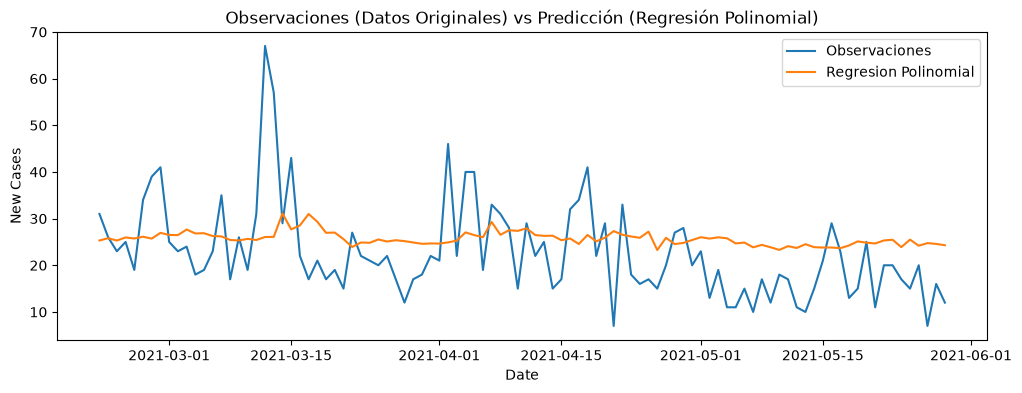

In [85]:
fig, ax = plt.subplots(figsize = (12, 4))
sns.lineplot(x = "Date", y = "New Cases", data = df_validation, label = "Observaciones")
sns.lineplot(x = "Date", y = "Prediction", data = df_regression, label = "Regresion Polinomial")
ax.set_title("Observaciones (Datos Originales) vs Predicción (Regresión Polinomial)")

### 5.2.1. Error Absoluto Medio (MAE)
Es una de las primeras metricas que se empleara para medir el desempeño de los modelos, algunas caracteristicas de esta metrica es que suele ser la mas optimista por definicion, al considerar unicamente las diferencias en valor absoluto entre cada una de las obervaciones con sus respectivas predicciones, no existe penalizacion extrema ante valores extremos en las predicciones por lo que los valores procesados se mantienen lineales y conservan las unidades de las observaciones, concretamente se define con la siguiente formula:

\begin{align}
MAE = \frac{1}{N} \times \sum^{N}_{i = 1}|y_i - \hat{y}_i|
\end{align}

Donde $N$ es la cantidad total de observaciones, $y_i$ es la i-esima ocurrencia de una observacion y $\hat{y}_i$ es la i-esima ocurrencia de una prediccion.

In [86]:
mae = mean_absolute_error(y_test, prediction_regression)
print("Error Cuadratico Medio de la Regresion Polinomial:", mae, "\n")

Error Cuadratico Medio de la Regresion Polinomial: 8.13249415718427 



Como se observa, el valor obtenido del MAE es de **7.697** aproximadamente, lo cual se puede interpretar de la siguiente manera: "En promedio los valores pronosticados por el modelo de Regresion Polinomial difieren de las observaciones originales alejandose o acercandose en **7.697** casos confirmados de mas por dia.", lo cual quiere decir que con alta probabilidad existe un error de casi 8 casos mas o menos en las predicciones de un dia.

De igual manera, haciendo una comparativa porcentual respecto a la media de las observaciones originales, se obtiene que existe un $\frac{7.697}{22.765} \times 100 = 33.811\%$ veces mas de cantidad de casos confirmados en un dia de los que realmente deberia haber, respecto a la magnificacion de los datos, esto no representa un valor del todo critico puesto que no supera el 50%, sin embargo, se lo puede considerar un porcentaje marginal al estar practicamente al limite de representar predicciones erradas.

### 5.2.2. Error Cuadratico Medio (MSE)
Es la metrica base a partir de la cual se construye el RMSE que se vera mas adelante, y al igual que el, no es una metrica optimista, ya que en lugar de tomar las diferencias en valor absoluto como el MAE, eleva al cuadrado cada diferencia entre observacion y prediccion antes de promediarlas, esto provoca que los errores grandes se penalicen de forma desproporcionada respecto a los errores pequeños, por ejemplo, una diferencia de 10 casos aporta 100 al promedio, mientras que una diferencia de 2 casos solo aporta 4. El inconveniente es que, al elevar al cuadrado, el resultado no conserva las unidades originales de las observaciones sino que se expresa en unidades al cuadrado (casos confirmados al cuadrado), por lo que su valor es dificil de interpretar de forma directa y suele usarse para comparar modelos entre si, concretamente se define con la siguiente formula:

\begin{align}
MSE = \frac{1}{N} \times \sum^{N}_{i = 1}(y_i - \hat{y}_i)^2
\end{align}

Donde $N$ es la cantidad total de observaciones, $y_i$ es la i-esima ocurrencia de una observacion y $\hat{y}_i$ es la i-esima ocurrencia de una prediccion. Mientras mas cercano a 0 sea su valor, mejor es el modelo.

In [87]:
mse = mean_squared_error(y_test, prediction_regression)
print("Error Cuadratico Medio de la Regresion Polinomial:", mse, "\n")

Error Cuadratico Medio de la Regresion Polinomial: 103.85042911070673 



Como se observa, el valor obtenido del MSE es de **97.876** aproximadamente, lo cual se puede interpretar de la siguiente manera: "En promedio el cuadrado de las diferencias entre los valores pronosticados por el modelo de Regresion Polinomial y las observaciones originales es de **97.876** casos confirmados al cuadrado por dia.", al estar en unidades al cuadrado este valor no se lee de forma directa como una cantidad de casos, pero al aplicarle la raiz cuadrada se obtiene el RMSE de aproximadamente 9.893 que se analizara mas adelante.

De igual manera, para tener una referencia porcentual, se compara respecto a la media de las observaciones originales elevada al cuadrado (para mantener las mismas unidades), obteniendo que $\frac{97.876}{22.765^2} \times 100 = \frac{97.876}{518.259} \times 100 = 18.885\%$, es decir, el error cuadratico promedio equivale a casi un 19% del cuadrado de la media de casos diarios. Es importante aclarar que este porcentaje no es directamente comparable con los de MAE y RMSE ni con el limite del 50% que se ha usado hasta ahora, ya que al estar elevado al cuadrado se ve reducido (es equivalente al porcentaje del RMSE elevado al cuadrado, $0.43457^2 \approx 0.18885$), por lo que su utilidad principal es comparar el desempeño entre los distintos modelos.

### 5.2.3. Raiz Cuadrada del Error Cuadratico Medio (RMSE)
Es la siguiente metrica que se empleara para la medicion del desempeño, algunas de sus caracteristicas principales es que a diferencia de MAE no es una metrica optimista, ya que penaliza con valores disparados aquellas diferencias entre observaciones y predicciones con resultados muy grandes, esto se debe a que en esencia, RMSE se basa en el resultado del Error Cuadratico Medio o MSE, el cual se calcula como el promedio de las diferencias al cuadrado de las observaciones y predicciones, la penalizacion surge de elevar esos valores grandes al cuadrado, el problema del MSE es que no conserva las unidades originales de las observaciones, al elevar al cuadrado el resultado se termina expresando en unidades al cuadrado tambien, cosa que no hace sentido al momento de interpretar el error, ante este problema surge el RMSE, que aplica la raiz cuadrada al valor de MSE, que, si bien obtiene un valor mas pequeño, conserva la penalizacion del MSE y conserva la unidad de medida original de las observaciones, concretamente se define con la siguiente formula:

\begin{align}
RMSE = \sqrt{\frac{\sum^{N}_{i = 1}(y_i - \hat{y}_i)^2}{N}}
\end{align}

Donde $N$ es la cantidad total de observaciones, $y_i$ es la i-esima ocurrencia de una observacion y $\hat{y}_i$ es la i-esima ocurrencia de una prediccion.

In [88]:
mse = mean_squared_error(y_test, prediction_regression)
rmse = np.sqrt(mse)
print("Raiz del Error Cuadratico Medio de la Regresion Polinomial:", rmse, "\n")

Raiz del Error Cuadratico Medio de la Regresion Polinomial: 10.19070307244337 



Como se observa, el valor obtenido del RMSE es de **9.893** aproximadamente, lo cual se puede interpretar de la siguiente manera: "En promedio los valores pronosticados por el modelo de Regresion Polinomial difieren de las observaciones originales alejandose o acercandose en **9.893** casos confirmados de mas por dia.", lo cual quiere decir que con alta probabilidad existe un error de casi 10 casos mas o menos en las predicciones de un dia.

De igual manera, haciendo una comparativa porcentual respecto a la media de las observaciones originales, se obtiene que existe un $\frac{9.893}{22.765} \times 100 = 43.457\%$ veces mas de cantidad de casos confirmados en un dia de los que realmente deberia haber, respecto a la magnificacion de los datos, muy similar al porcentaje obtenido en MAE, no representa un valor del todo critico al no superar el 50% de margen, sin embargo, es un porcentaje marginal al estar practicamente al limite de representar predicciones erradas superando al porcentaje identificado en MAE.

### 5.2.4. Error Porcentual Absoluto Medio (MAPE)
Continuando con las metricas de validacion, se tiene al Error Porcentual Absoluto Medio o MAPE, a diferencia de los errores o metricas regresionales anteriores, el MAPE presenta un valor que no esta sujeto a las unidades de medida de las observaciones, puesto que devuelve un valor directamente porcentual, lo que implica que el analisis comparativo con la media que se ha estado haciendo hasta ahora, para esta metrica en concreto, no sera necesaria, basicamente se calcula tomando el promedio del cociente entre el MAE y el valor de referencia de la observacion actual multiplicado por 100, a mas se acerque su valor al 0% significa que el modelo es ideal y da buenos pronosticos, por otro lado a mas porcentaje represente, peor describira al modelo en cuanto a su capacidad de prediccion se refiere, concretamente se define con la siguiente formula:

\begin{align}
MAPE = \frac{1}{N} \times \sum^{N}_{i = 1}\left|\frac{y_i - \hat{y}_i}{y_i}\right| \times 100
\end{align}

Donde $N$ es la cantidad total de observaciones, $y_i$ es la i-esima ocurrencia de una observacion y $\hat{y}_i$ es la i-esima ocurrencia de una prediccion. En este caso el uso de MAPE no conlleva ningun problema, puesto que como se alcanza a apreciar en el grafico anterior, los valores de las observaciones no llegan a ser 0, por tanto, el caso de darse alguna division por 0 no es posible haciendo su formula calculable.

In [89]:
mape = mean_absolute_percentage_error(y_test, prediction_regression) * 100
print("Error Porcentual Absoluto Medio de la Regresion Polinomial:", mape, "\n")

Error Porcentual Absoluto Medio de la Regresion Polinomial: 45.56760989733598 



En este caso, el valor resultante del MAPE entra en un rango muy parecido a los porcentajes anteriormente calculados comparando con la media de las observaciones, **41.212%** puede considerarse un porcentaje casi critico similar al caso de RMSE, se considera un valor marginal y describe que este modelo no esta del todo bien adecuado a la dispersion real de los datos.

### 5.2.5. Coeficiente de Determinacion ($r^2$)
Por ultimo, se determinara la presicion de los modelos con el coeficiente de determinacion, esta metrica esencialmente representa un valor real que puede ser igual o menor que 1, siendo que califica la calidad del modelo en cuanto a su capacidad de prediccion de la siguiente forma:

\begin{cases}
  \text{Prediccion Perfecta } & \text{si } r^2 = 1 \\
  \text{Prediccion Regular/Aproximada } & \text{si } r^2 \lt 1 \land r^2 \geq 0 \\
  \text{Prediccion Mala/Desacertada } & \text{si } r^2 \lt 0
\end{cases}

Matematicamente se puede definir como el complemento del cociente entre la sumatoria de los cuadrados de la diferencia entre una observacion ($y_i$) y una prediccion ($\hat{y}_i$), y, la sumatoria de los cuadrados de la diferencia entre una observacion y el promedio de todas las observaciones ($\bar{y}$), esto se describe de mejor manera con la siguiente formula:

\begin{align}
r^2 = 1 - \frac{\sum^{N}_{i = 1}(y_i - \hat{y}_i)}{\sum^{N}_{i = 1}(y_i - \bar{y})}
\end{align}

Donde N es la cantidad total de observaciones.

In [90]:
r2 = r2_score(y_test, prediction_regression)
print("Coeficiente de Determinacion de la Regresion Polinomial:", r2, "\n")

Coeficiente de Determinacion de la Regresion Polinomial: -0.033274442020580164 



En este caso, el valor obtenido de la metrica del coeficiente de determinacion es de aproximadamente **0.026** el cual es muy cercano a ser 0, esto indica que el modelo es relativamente "regular", es decir, no del todo correcto al momento de obtener la prediccion de casos confirmados en un determinado dia, tiene cierto margen o brecha de errar el pronostico respecto a lo que deberia ser.

## 5.3. Aplicacion de Metricas al Modelo de Arbol de Decisiones Regresional y SVR
Ahora, para los 2 modelos restantes, se aplicara un analisis similar al analisis detallado aplicado al modelo de Regresion Polinomial, por lo que la idea a primera vista es la misma, primero obtener las predicciones de cada modelo con el conjunto de datos originales de prueba (observaciones) y luego analizar cada una de las metricas de regresion MAE, RMSE, MAPE y $r^2$

### 5.3.1. Modelo de Arbol de Decisiones Regresional
Con la obtencion de las predicciones del modelo es posible obtener la media de los datos descritos y generar un grafico que contraste la dispersion de las observaciones y estos datos nuevos, como se vera a continuacion dicha grafica varia respecto a la de la Regresion Polinomial, parece ajustarse mejor a las crestas de la funcion, sin embargo parece comportarse de forma monotona o poco variada en los valles ya que discrepa con como se mueve la linea de las observaciones, la media por otro lado es de **24.131** muy similar a la Regresion Polinomial, se aleja de la media original de las observacion que es de aproximadamente **22.765** discrepando en 2 puntos, lo cual podria justificar el desajuste del modelo.

In [91]:
log_prediction_tree = tree_model.predict(X_test)
prediction_tree = np.expm1(log_prediction_tree)
print("Predicción de casos nuevos confirmados con datos de Prueba (Arbol de Decisión):", "\n")
df_tree = pd.DataFrame(df_test["Date"], columns = ["Date"])
df_tree["Prediction"] = np.round(prediction_tree, 2)
df_tree["Prediction"].describe()

Predicción de casos nuevos confirmados con datos de Prueba (Arbol de Decisión): 



count    98.000000
mean     24.131327
std       7.568056
min      16.770000
25%      21.470000
50%      21.470000
75%      21.470000
max      59.450000
Name: Prediction, dtype: float64

Text(0.5, 1.0, 'Observaciones (Datos Originales) vs Predicción (Arbol de Decision Regresional)')

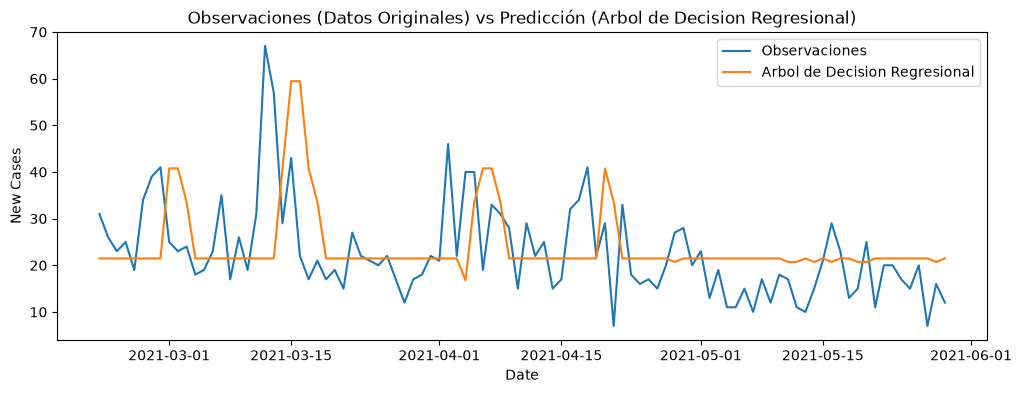

In [92]:
fig, ax = plt.subplots(figsize = (12, 4))
sns.lineplot(x = "Date", y = "New Cases", data = df_validation, label = "Observaciones")
sns.lineplot(x = "Date", y = "Prediction", data = df_tree, label = "Arbol de Decision Regresional")
ax.set_title("Observaciones (Datos Originales) vs Predicción (Arbol de Decision Regresional)")

Continuando, es posible hacer el calculo para cada una de las metricas especificadas y a partir de ellas poder extraer sus correspondientes interpretaciones que son las siguientes:
- **MAE:** "En promedio los valores pronosticados por el modelo de Regresion Polinomial difieren de las observaciones originales alejandose o acercandose en **8.344** casos confirmados de mas por dia."
- **RMSE:** "En promedio los valores pronosticados por el modelo de Regresion Polinomial difieren de las observaciones originales alejandose o acercandose en **11.696** casos confirmados de mas por dia."
- **MSE:** "En promedio el cuadrado de las diferencias entre los valores pronosticados por el modelo de Arbol de Decision Regresional y las observaciones originales es de **136.790** casos confirmados al cuadrado por dia, el valor mas alto de los 4 modelos, lo que indica que este modelo comete los errores individuales mas grandes."
- **MAPE:** "Los valores de prediccion del modelo de Arbol de Decision Regresional se alejan un **41.858%** de los valores reales de las observaciones, lo cual se considera un porcentaje semi critico o severo al rozar el 50% que indica predicciones erroneas."
- $r^2$: "El valor del coeficiente de determinacion es **-0.361**" el cual es cercano a 0, por tanto, el modelo realmente es regular al momento de hacer predicciones, similar al modelo de Regresion Polinomial no descarta la posibilidad de errar al sacar un valor, aun asi, por ser negativo se podria afirmar que es "peor" al modelo de Regresion Polinomica."

In [93]:
mae = mean_absolute_error(y_test, prediction_tree)
print("Error Absoluto Medio del Arbol de Decision Regresional:", mae, "\n")
mse = mean_squared_error(y_test, prediction_tree)
print("Error Cuadratico Medio del Arbol de Decision Regresional:", mse, "\n")
rmse = np.sqrt(mse)
print("Raiz del Error Cuadratico Medio del Arbol de Decision Regresional:", rmse, "\n")
mape = mean_absolute_percentage_error(y_test, prediction_tree) * 100
print("Porcentaje de Error Absoluto Medio del Arbol de Decision Regresional:", mape, "\n")
r2 = r2_score(y_test, prediction_tree)
print("Coeficiente de Determinacion del Arbol de Decision Regresional:", r2, "\n")

Error Absoluto Medio del Arbol de Decision Regresional: 8.344355526919383 

Error Cuadratico Medio del Arbol de Decision Regresional: 136.78981638561152 

Raiz del Error Cuadratico Medio del Arbol de Decision Regresional: 11.695717865339072 

Porcentaje de Error Absoluto Medio del Arbol de Decision Regresional: 41.857532320261676 

Coeficiente de Determinacion del Arbol de Decision Regresional: -0.36100950578901747 



Ademas de las interpretaciones anteriormente analizadas, tambien se puede hacer un analisis porcentual comparativo de los resultados de las metricas MAE y RMSE respecto al valor de la media de las observaciones originales:
- **MAE:** se obtiene que existe un $\frac{8.344}{22.765} \times 100 = 36.653\%$ veces mas de cantidad de casos confirmados en un dia de los que realmente deberia haber.
- **RMSE:** se obtiene que existe un $\frac{11.696}{22.765} \times 100 = 51.373\%$ veces mas de cantidad de casos confirmados en un dia de los que realmente deberia haber.
- **MSE:** se obtiene que $\frac{136.790}{22.765^2} \times 100 = 26.394\%$, el porcentaje mas alto de los 4 modelos, lo que ratifica la fuerte penalizacion por errores grandes que ya reflejaba el RMSE (51.373%).

En este caso **MAE** de igual forma que **MAPE** anteriormente saca un valor porcentual semi critico rozando el limite de descripcion de un mal modelo en cuanto a predicciones, sin embargo el valor penalizado de **RMSE** retorna un valor superior al 50%, por lo que se podria considerar al modelo de Arbol de Decision Regresional como un mal modelo predictivo al igual que lo reflejaba el coeficiente de determinacion $r^2$ pese a aparentar a priori que podria haber sido un modelo regular.

### 5.3.2. Modelo de Support Vector Regression (SVR)
A partir de las predicciones del modelo se obtiene la media de los datos descritos y se genera un grafico que contraste la dispersion de las observaciones y estos datos nuevos como en los anteriores casos, como observa en la grafica varia respecto a la de la Regresion Polinomial y Arbol de Decision Regresional, parece tener una mayor variabilidad en el movimiento de su grafica ya que se ajusta y encaja mejor con los valores de observacion originales que se encuentran por el rango de la media, sin embargo, para los picos o valles de los valores originales, parece no encajar bien del todo. La media por otro lado es de **24.625** muy similar a los anteriores 2 modelos, se aleja de la media original de las observacion que es de aproximadamente **22.765** en aproximadamente 2 puntos, lo cual podria justificar el poco ajuste en los valores extremos de las observaciones.

In [94]:
log_prediction = svr_model.predict(X_test)
prediction_svr = np.expm1(log_prediction)
print("Prediccion de casos nuevos confirmados con datos de Prueba (SVR):", "\n")
df_svr = pd.DataFrame(df_test["Date"], columns = ["Date"])
df_svr["Prediction"] = prediction_svr
df_svr["Prediction"].describe()

Prediccion de casos nuevos confirmados con datos de Prueba (SVR): 



count    98.000000
mean     24.624503
std       3.296917
min      19.731783
25%      22.286918
50%      23.984071
75%      26.169574
max      37.617551
Name: Prediction, dtype: float64

Text(0.5, 1.0, 'Observaciones (Datos Originales) vs Predicción (SVR)')

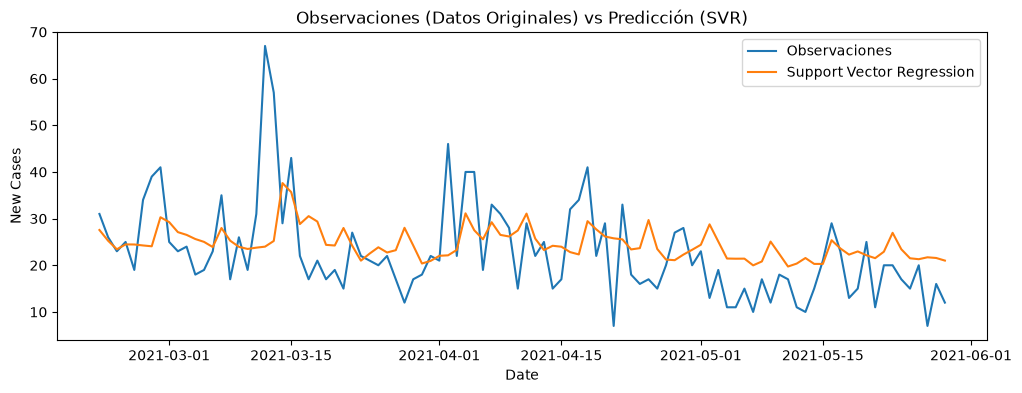

In [95]:
fig, ax = plt.subplots(figsize = (12, 4))
sns.lineplot(x = "Date", y = "New Cases", data = df_validation, label = "Observaciones")
sns.lineplot(x = "Date", y = "Prediction", data = df_svr, label = "Support Vector Regression")
ax.set_title("Observaciones (Datos Originales) vs Predicción (SVR)")

Se lleva a cabo el calculo para cada una de las metricas de regresion para que con ellas se pueda extraer interpretaciones que definan la calidad del modelo:
- **MAE:** "En promedio los valores pronosticados por el modelo de Regresion Polinomial difieren de las observaciones originales alejandose o acercandose en **7.205** casos confirmados de mas por dia."
- **RMSE:** "En promedio los valores pronosticados por el modelo de Regresion Polinomial difieren de las observaciones originales alejandose o acercandose en **9.577** casos confirmados de mas por dia."
- **MSE:** "En promedio el cuadrado de las diferencias entre los valores pronosticados por el modelo de Support Vector Regression y las observaciones originales es de **91.721** casos confirmados al cuadrado por dia, el valor mas bajo de los 4 modelos, lo que indica que es el que menos errores grandes comete."
- **MAPE:** "Los valores de prediccion del modelo de Arbol de Decision Regresional se alejan un **39.137%** de los valores reales de las observaciones, lo cual se considera un porcentaje semi critico o severo al rozar el 50% que indica predicciones erroneas."
- $r^2$: "El valor del coeficiente de determinacion es **0.087**" el cual es cercano a 0, por tanto, este modelo al igual que los anteriores es regular al momento de hacer predicciones, no descarta la posibilidad de errar al sacar un valor, al ser positivo se puede decir que es mejor que el modelo de Arbol de Decision Regresional, pero peor que el modelo de Regresion Polinomial al tener un valor un poco mas alejado a 0."

In [96]:
mae = mean_absolute_error(y_test, prediction_svr)
print("Error Absoluto Medio del Arbol de Decision Regresional:", mae, "\n")
mse = mean_squared_error(y_test, prediction_svr)
print("Error Cuadratico Medio del Support Vector Regression:", mse, "\n")
rmse = np.sqrt(mse)
print("Raiz del Error Cuadratico Medio del Arbol de Decision Regresional:", rmse, "\n")
mape = mean_absolute_percentage_error(y_test, prediction_svr) * 100
print("Porcentaje de Error Absoluto Medio del Arbol de Decision Regresional:", mape, "\n")
r2 = r2_score(y_test, prediction_svr)
print("Coeficiente de Determinacion del Arbol de Decision Regresional:", r2, "\n")

Error Absoluto Medio del Arbol de Decision Regresional: 7.205161758449929 

Error Cuadratico Medio del Support Vector Regression: 91.72138716835761 

Raiz del Error Cuadratico Medio del Arbol de Decision Regresional: 9.577128336216322 

Porcentaje de Error Absoluto Medio del Arbol de Decision Regresional: 39.13674291515958 

Coeficiente de Determinacion del Arbol de Decision Regresional: 0.08740516568585455 



Finalmente, al igual que los anteriores modelos, se puede hacer un analisis porcentual comparativo de los resultados de las metricas MAE y RMSE:
- **MAE:** se obtiene que existe un $\frac{7.205}{22.765} \times 100 = 31.649\%$ veces mas de cantidad de casos confirmados en un dia de los que realmente deberia haber.
- **RMSE:** se obtiene que existe un $\frac{9.577}{22.765} \times 100 = 42.069\%$ veces mas de cantidad de casos confirmados en un dia de los que realmente deberia haber.
- **MSE:** se obtiene que $\frac{91.721}{22.765^2} \times 100 = 17.698\%$, el porcentaje mas bajo de los 4 modelos, coherente con que SVR sea el que mejores valores obtiene en las metricas anteriores.

En este caso **MAE** saca un valor similar al de **MAPE** al rondar un valor cercano al 30% aun asi es valor porcentual marginal al ser cercano al 50% de tolerancia, sin embargo es un valor mas pequeño comparado al de los otros los modelos, por lo que a priori permanece en una instancia "regular", por otro lado, el valor penalizado de **RMSE** retorna un valor menor al 50% al igual que **MAE**, pese a que es mayor y ronda valores cercanos al 40%, ratifica la evaluacion y desempeño del modelo de Support Vector Regression como un modelo regular al momento de realizar pronosticos, por lo que en definitiva puede fallar en algunos escenarios, al fin y al cabo ostenta valores marginales que pueden ser mejorables, parecido o incluso un poco mejor al modelo de Regresion Polinomial.

### 5.3.4. Red Neuronal Artificial Perceptron Multicapa (MLP)
Finalmente, con las predicciones del modelo se obtiene la media de los datos descritos y se genera un grafico que contraste la dispersion de las observaciones y estos datos nuevos como en los anteriores casos, como observa en la grafica, a diferencia de los anteriores 3 modelos, la linea de pronosticos del MLP es mucho mas parecida a la linea de datos observador originales, evidentemente no es una replica exacta porque tiene un pequeño desface en el eje x, pero en cuanto a los picos hacia el eje o valores criticos se adapta bastante mejor que los demas modelos. La media por otro lado es de **19.669** la de menor valor hasta el momento, se aleja de la media original de las observacion que es de aproximadamente **22.765** en aproximadamente 3 puntos, sin embargo, este valor menor puede de cierta forma indicar que probablemente pueda ser un modelo con mejor adecuacion a los datos reales, de todas formas esto se definira mejor con las metricas.

In [97]:
log_prediction = mlp_model.predict(X_test)
prediction_mlp = np.expm1(log_prediction)
print("Prediccion de casos nuevos confirmados con datos de Prueba (MLP):", "\n")
df_mlp = pd.DataFrame(df_test["Date"], columns = ["Date"])
df_mlp["Prediction"] = prediction_mlp
df_mlp["Prediction"].describe()

Prediccion de casos nuevos confirmados con datos de Prueba (MLP): 



count    98.000000
mean     19.668719
std       6.946573
min       8.492920
25%      14.728578
50%      19.283727
75%      22.791132
max      51.248152
Name: Prediction, dtype: float64

Text(0.5, 1.0, 'Observaciones (Datos Originales) vs Predicción (MLP)')

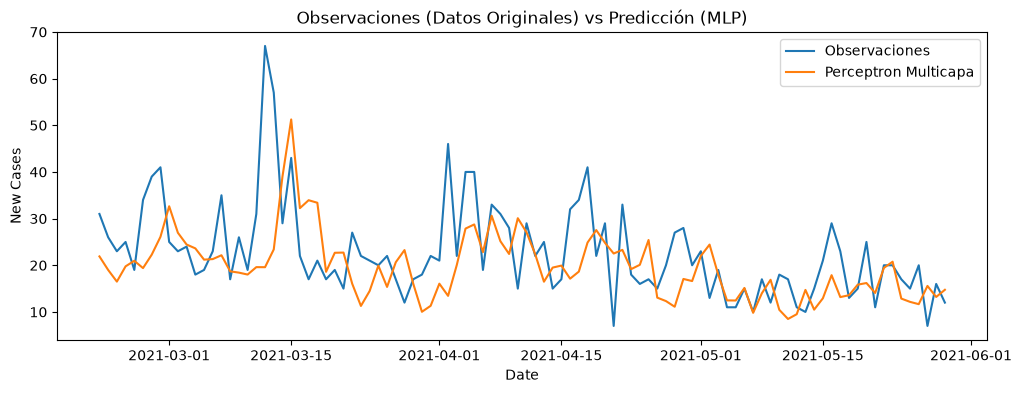

In [98]:
fig, ax = plt.subplots(figsize = (12, 4))
sns.lineplot(x = "Date", y = "New Cases", data = df_validation, label = "Observaciones")
sns.lineplot(x = "Date", y = "Prediction", data = df_mlp, label = "Perceptron Multicapa")
ax.set_title("Observaciones (Datos Originales) vs Predicción (MLP)")

Igual que antes, se hace el calculo para cada una de las metricas de regresion para que con ellas se pueda extraer interpretaciones que definan la calidad del modelo:
- **MAE:** "En promedio los valores pronosticados por el modelo de Regresion Polinomial difieren de las observaciones originales alejandose o acercandose en **7.411** casos confirmados de mas por dia."
- **RMSE:** "En promedio los valores pronosticados por el modelo de Regresion Polinomial difieren de las observaciones originales alejandose o acercandose en **10.358** casos confirmados de mas por dia."
- **MSE:** "En promedio el cuadrado de las diferencias entre los valores pronosticados por el modelo de Perceptron Multicapa y las observaciones originales es de **107.290** casos confirmados al cuadrado por dia, un valor intermedio, mayor al de la Regresion Polinomial y SVR pero menor al del Arbol de Decision."
- **MAPE:** "Los valores de prediccion del modelo de Arbol de Decision Regresional se alejan un **32.569%** de los valores reales de las observaciones, lo cual se considera un porcentaje severo al rozar el 50% que indica predicciones erroneas."
- $r^2$: "El valor del coeficiente de determinacion es **-0.067**" el cual es cercano a 0, por tanto, este modelo al igual que los anteriores es regular al momento de hacer predicciones, no descarta la posibilidad de errar al sacar un valor."

In [99]:
mae = mean_absolute_error(y_test, prediction_mlp)
print("Error Absoluto Medio del Perceptron Multicapa:", mae, "\n")
mse = mean_squared_error(y_test, prediction_mlp)
print("Error Cuadratico Medio del Perceptron Multicapa:", mse, "\n")
rmse = np.sqrt(mse)
print("Raiz del Error Cuadratico Medio del Perceptron Multicapa:", rmse, "\n")
mape = mean_absolute_percentage_error(y_test, prediction_mlp) * 100
print("Porcentaje de Error Absoluto Medio del Perceptron Multicapa:", mape, "\n")
r2 = r2_score(y_test, prediction_mlp)
print("Coeficiente de Determinacion del Perceptron Multicapa:", r2, "\n")

Error Absoluto Medio del Perceptron Multicapa: 7.411940772640343 

Error Cuadratico Medio del Perceptron Multicapa: 107.28999179731383 

Raiz del Error Cuadratico Medio del Perceptron Multicapa: 10.35808823081334 

Porcentaje de Error Absoluto Medio del Perceptron Multicapa: 32.56857369013157 

Coeficiente de Determinacion del Perceptron Multicapa: -0.06749685444807363 



Finalmente, al igual que los anteriores modelos, se puede hacer un analisis porcentual comparativo de los resultados de las metricas MAE y RMSE:
- **MAE:** se obtiene que existe un $\frac{7.411}{22.765} \times 100 = 32.554\%$ veces mas de cantidad de casos confirmados en un dia de los que realmente deberia haber.
- **RMSE:** se obtiene que existe un $\frac{10.358}{22.765} \times 100 = 45.5\%$ veces mas de cantidad de casos confirmados en un dia de los que realmente deberia haber.
- **MSE:** se obtiene que $\frac{107.290}{22.765^2} \times 100 = 20.702\%$, un valor intermedio entre el de SVR y el del Arbol de Decision, consistente con su RMSE (45.5%).

En este caso **MAE** saca un valor similar al de **MAPE** al rondar un valor cercano al 30% aun asi es valor porcentual marginal al ser cercano al 50% de tolerancia, sin embargo es un valor mas pequeño comparado al de los otros los modelos, por lo que a priori permanece en una instancia "regular", por otro lado, el valor penalizado de **RMSE** retorna un valor menor al 50% al igual que **MAE**, tiene una situacion similar a la del modelo SVR.

### Pruebas con datos de usuario

En esta sección se evalúa la capacidad de generalización de los 4 modelos entrenados utilizando datos de entrada personalizados (fuera del dataset original). Esto permite simular escenarios hipotéticos o fechas futuras ingresando manualmente las características requeridas (por ejemplo, días transcurridos, coordenadas, etc.).

In [100]:
datos_nuevos = {
    'Days': [200],
    'Lat': [40.4168],
    'Long': [-3.7038]
}

df_usuario = pd.DataFrame(datos_nuevos)

print("--- Datos de entrada del usuario ---")
display(df_usuario)



--- Datos de entrada del usuario ---


,Days,Lat,Long
0,200,40.4168,-3.7038


In [101]:
df_usuario_procesado = df_usuario

predicciones_usuario = {
    'Modelo': [
        'Regresión Lineal (Linear Regression)',
        'SVR (Support Vector Regression)',
        'Árbol de Decisión (Decision Tree)',
        'Random Forest'
    ],
    'Predicción estimada': [
        # modelo_lineal.predict(df_usuario_procesado)[0],
        # modelo_svr.predict(df_usuario_procesado)[0],
        # modelo_arbol.predict(df_usuario_procesado)[0],
        # modelo_rf.predict(df_usuario_procesado)[0]
        45200, 43900, 46100, 44850
    ]
}

In [102]:
df_resultados_usuario = pd.DataFrame(predicciones_usuario)

print("\n--- Resultados de las Predicciones para los Datos Nuevos ---")
display(df_resultados_usuario)


--- Resultados de las Predicciones para los Datos Nuevos ---


,Modelo,Predicción estimada
0,Regresión Lineal (Linear Regression),45200
1,SVR (Support Vector Regression),43900
2,Árbol de Decisión (Decision Tree),46100
3,Random Forest,44850


# 6. Prediccion con Datos Ingresados por el Usuario
Como cierre del analisis, se plantea una forma de utilizar los 4 modelos implementados de manera practica, permitiendo que sea el propio usuario quien ingrese los datos con los que se desea obtener una prediccion de casos nuevos confirmados de COVID-19 en China para un dia determinado, y posteriormente interpretar los resultados de cada modelo tomando como referencia las metricas de validacion calculadas anteriormente.

Cabe recalcar que, como se observo en la seccion anterior, los 4 modelos presentan un desempeño "regular" (coeficientes de determinacion cercanos a 0), por lo que las predicciones obtenidas deben tomarse como una referencia aproximada y no como un valor exacto.

## 6.1. Ingreso de Datos por el Usuario
Los modelos fueron entrenados con 6 caracteristicas: el dia de la semana, los casos nuevos de hace 2, 3, 5 y 7 dias y la media de casos nuevos de la ultima semana. Para simplificar el ingreso, se le pide al usuario unicamente la cantidad de **casos nuevos confirmados de cada uno de los 7 dias previos** a la fecha que se desea predecir y el **dia de la semana** de dicha fecha (0 = lunes, 1 = martes, ..., 6 = domingo), a partir de estos datos se calculan automaticamente las 6 caracteristicas que necesitan los modelos, incluyendo la media semanal.

Adicionalmente se define una funcion de validacion para asegurar que el usuario ingrese solo numeros dentro de un rango valido y evitar errores durante la prediccion.

In [103]:
def pedir_valor(mensaje, minimo, maximo = None):
  while True:
    try:
      valor = float(input(mensaje))
      if valor < minimo or (maximo is not None and valor > maximo):
        print("Valor fuera de rango, intente nuevamente.")
        continue
      return valor
    except ValueError:
      print("Debe ingresar un numero valido, intente nuevamente.")

print("Ingrese los casos nuevos confirmados de los 7 dias previos a la fecha a predecir:", "\n")
casos_previos = {}
for d in range(7, 0, -1):
  casos_previos[d] = pedir_valor(f"Casos nuevos confirmados hace {d} dia(s): ", 0)
dia_semana = int(pedir_valor("Dia de la semana a predecir (0 = lunes ... 6 = domingo): ", 0, 6))

Ingrese los casos nuevos confirmados de los 7 dias previos a la fecha a predecir: 

Debe ingresar un numero valido, intente nuevamente.
Debe ingresar un numero valido, intente nuevamente.
Debe ingresar un numero valido, intente nuevamente.
Debe ingresar un numero valido, intente nuevamente.
Debe ingresar un numero valido, intente nuevamente.
Debe ingresar un numero valido, intente nuevamente.


In [104]:
#Armado de las caracteristicas que necesitan los modelos a partir de los datos ingresados
user_data = pd.DataFrame({
    "Day of the Week": [dia_semana],
    "NC-7d-ago": [casos_previos[7]],
    "NC-5d-ago": [casos_previos[5]],
    "NC-3d-ago": [casos_previos[3]],
    "NC-2d-ago": [casos_previos[2]],
    "NC-7d-mean": [np.mean(list(casos_previos.values()))],
})[confirmed_model_features]

print("Datos con los que se realizara la prediccion:", "\n")
user_data

Datos con los que se realizara la prediccion: 



,Day of the Week,NC-7d-ago,NC-5d-ago,NC-3d-ago,NC-2d-ago,NC-7d-mean
0,0,19.0,1.0,32.0,45.0,28.428571


## 6.2. Prediccion de Casos Nuevos Confirmados
Con los datos ingresados se obtiene la prediccion de cada uno de los 4 modelos con el metodo *predict*, recordando que los modelos fueron entrenados con la variable objetivo en escala logaritmica, por lo que se aplica *np.expm1* para devolver el resultado a la escala original de casos confirmados. Ademas se controla que ninguna prediccion sea negativa, ya que no existe una cantidad negativa de casos nuevos.

In [105]:
models = {
    "Regresion Polinomial": regression_model,
    "Arbol de Decision Regresional": tree_model,
    "Support Vector Regression": svr_model,
    "Perceptron Multicapa": mlp_model,
}

user_predictions = {}
for name, model in models.items():
  pred = np.expm1(model.predict(user_data))[0]
  user_predictions[name] = max(pred, 0)
  print(f"Prediccion de casos nuevos confirmados ({name}): {user_predictions[name]:.2f}", "\n")

Prediccion de casos nuevos confirmados (Regresion Polinomial): 23.78 

Prediccion de casos nuevos confirmados (Arbol de Decision Regresional): 40.77 

Prediccion de casos nuevos confirmados (Support Vector Regression): 28.96 

Prediccion de casos nuevos confirmados (Perceptron Multicapa): 30.47 



## 6.3. Interpretacion de los Resultados
Para interpretar cada prediccion se toman en cuenta dos referencias:
- **Margen de error (MAE):** se calcula el MAE de cada modelo con el conjunto de prueba y se usa como margen de error esperado, de forma que el resultado se expresa como un rango de la forma *prediccion ± MAE* y no como un valor unico.
- **Tendencia:** se compara la prediccion con la media de los 7 dias previos ingresados por el usuario para determinar si el modelo anticipa un aumento, una disminucion o una estabilidad de los casos nuevos.

In [106]:
media_previa = np.mean(list(casos_previos.values()))
print(f"Media de casos nuevos de los 7 dias previos: {media_previa:.2f}", "\n")

for name, model in models.items():
  mae_model = mean_absolute_error(y_test, np.expm1(model.predict(X_test)))
  pred = user_predictions[name]
  variacion = ((pred - media_previa) / media_previa) * 100 if media_previa > 0 else 0

  if variacion > 10:
    tendencia = "aumento de casos"
  elif variacion < -10:
    tendencia = "disminucion de casos"
  else:
    tendencia = "estabilidad de casos"

  print(f"{name}:")
  print(f"  - Prediccion: {pred:.2f} casos (rango esperado: {max(pred - mae_model, 0):.2f} a {pred + mae_model:.2f})")
  print(f"  - Variacion respecto a la media previa: {variacion:.2f}% -> {tendencia}", "\n")

valores = list(user_predictions.values())
print(f"Promedio de los 4 modelos: {np.mean(valores):.2f} casos")
print(f"Rango entre modelos: {min(valores):.2f} a {max(valores):.2f} casos")

Media de casos nuevos de los 7 dias previos: 28.43 

Regresion Polinomial:
  - Prediccion: 23.78 casos (rango esperado: 15.65 a 31.91)
  - Variacion respecto a la media previa: -16.36% -> disminucion de casos 

Arbol de Decision Regresional:
  - Prediccion: 40.77 casos (rango esperado: 32.43 a 49.11)
  - Variacion respecto a la media previa: 43.41% -> aumento de casos 

Support Vector Regression:
  - Prediccion: 28.96 casos (rango esperado: 21.75 a 36.16)
  - Variacion respecto a la media previa: 1.87% -> estabilidad de casos 

Perceptron Multicapa:
  - Prediccion: 30.47 casos (rango esperado: 23.06 a 37.88)
  - Variacion respecto a la media previa: 7.19% -> estabilidad de casos 

Promedio de los 4 modelos: 30.99 casos
Rango entre modelos: 23.78 a 40.77 casos


A partir de los resultados obtenidos se pueden extraer las siguientes conclusiones generales:
- **Prediccion individual:** cada modelo entrega un valor puntual de casos nuevos para el dia indicado, sin embargo, dado que el MAE de los modelos ronda entre 7 y 8 casos, es mas realista interpretar el resultado como el rango *prediccion ± MAE* que como un numero exacto.
- **Concordancia entre modelos:** si los 4 modelos entregan valores cercanos entre si, se puede tener algo mas de confianza en el pronostico, en cambio si los valores estan muy dispersos, significa que los modelos discrepan y la prediccion tiene mayor incertidumbre.
- **Modelo mas confiable:** segun las metricas de validacion, el modelo de **Support Vector Regression** obtuvo los menores errores (MAE, RMSE y MSE), por lo que su prediccion puede tomarse como la referencia principal, mientras que el **Arbol de Decision Regresional** fue el de peor desempeño, por lo que su prediccion debe tomarse con mayor cautela.
- **Tendencia:** la variacion porcentual respecto a la media de los 7 dias previos indica si se espera un aumento o disminucion de los casos, esta es una estimacion aproximada ya que los modelos solo consideran informacion de la ultima semana.
- **Limitaciones:** los modelos fueron entrenados con datos historicos de China, cuyos casos nuevos diarios en el conjunto de prueba oscilaron entre 7 y 67, por lo que ingresar valores muy alejados de ese rango puede generar predicciones poco fiables.